In [1]:
import papermill as pm
from jaxcmr.helpers import find_project_root
from IPython.display import Image, display
from matplotlib import rcParams  # type: ignore


# Render Reference Analyses

Render categorized descriptive analyses for the Talmi EEG project. These source cells prepare notebooks in `analyses/rendered/` from the analysis templates and preview the resulting reference figures.


In [ ]:
base_params = {
    "data_name": "TalmiEEG",
    "data_query": "data['subject'] > 0",
    "category_field": "condition",
    "contrast_name": "Source",
    "category_values": [1, 2],
    "labels": ["Negative", "Neutral"],
    "color_cycle": ["red", "black"],
    "ylim": [0.2, .8],
    "output_path": "figures/analyses/reference_catspc.png",
}

output_path = f"{find_project_root()}/analyses/rendered/cat_spc.ipynb"
print(output_path)
pm.execute_notebook(
    f"{find_project_root()}/analyses/templates/cat_spc.ipynb",
    output_path,
    parameters=base_params,
    progress_bar=False,
    prepare_only=True,
)

print(f"![]({base_params['output_path']})")
display(Image(filename=base_params["output_path"], width=600))

# Categorized LPP by Study Position

Plot LPP amplitude by study position, factored by categorical features (e.g., emotion tags).

results/figures/analyses/cat_lpp_spc_EarlyLPP.png


![](results/figures/analyses/cat_lpp_spc_EarlyLPP.png)


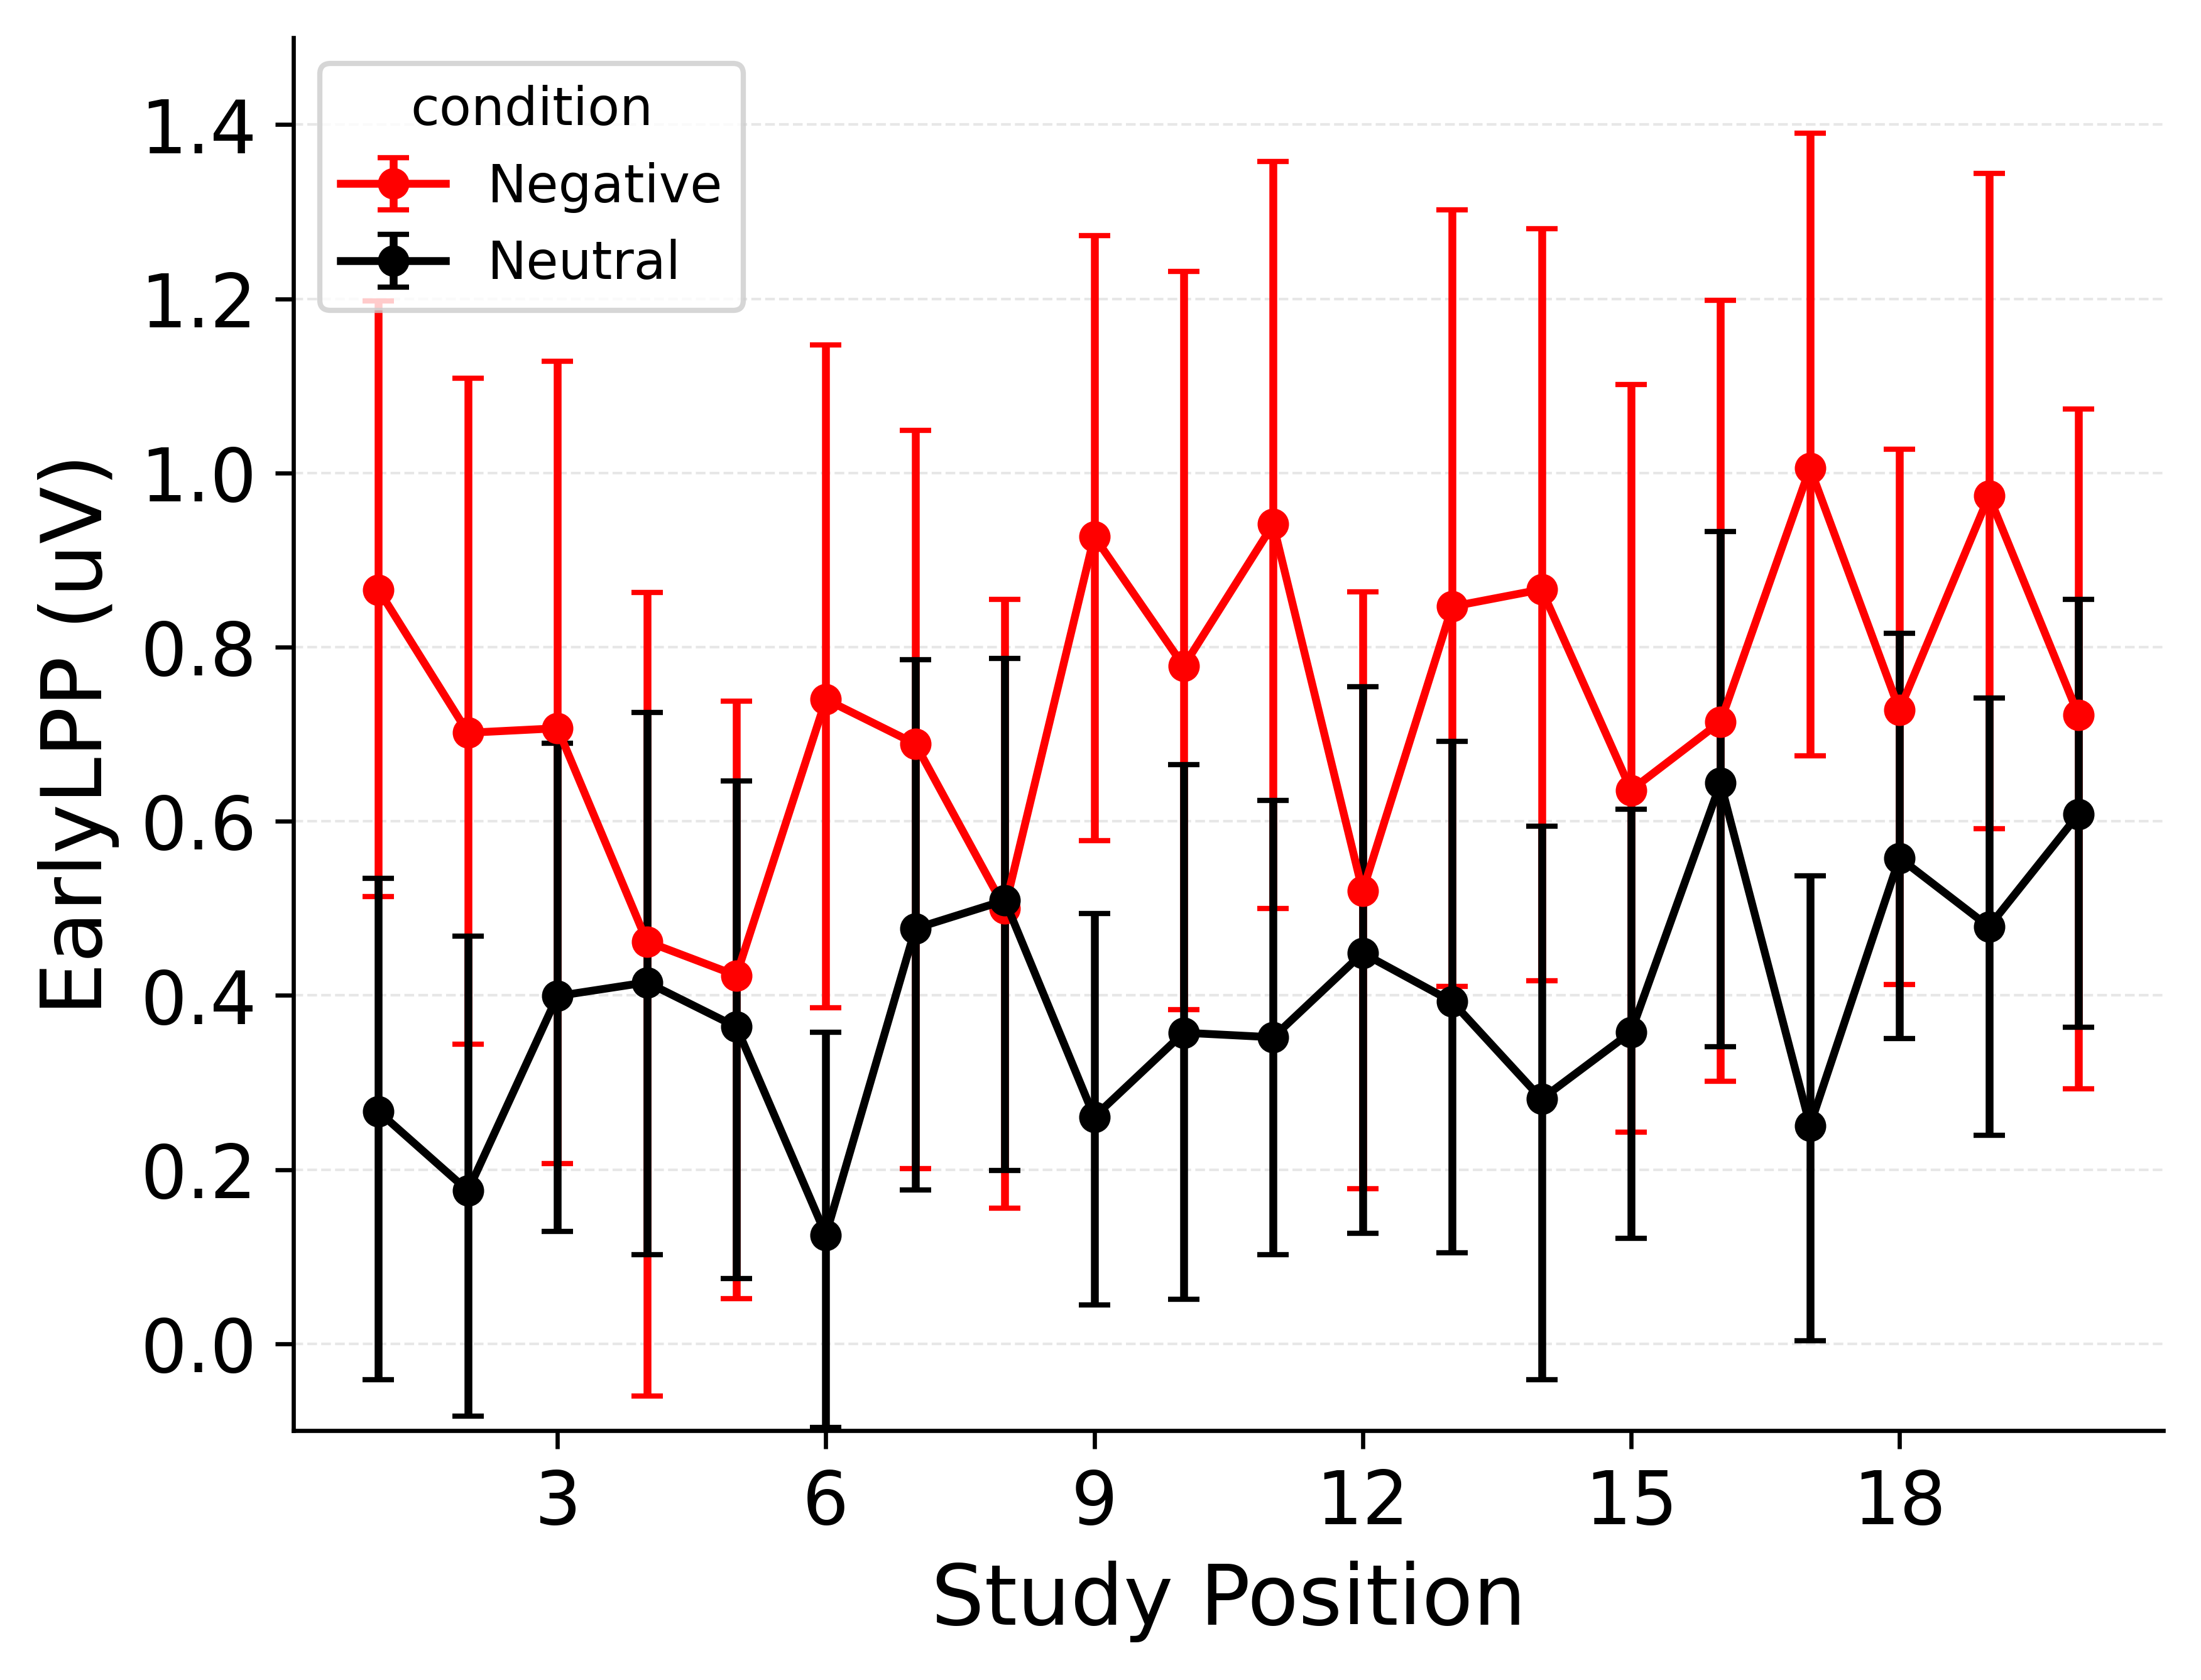

results/figures/analyses/cat_lpp_spc_LateLPP.png
![](results/figures/analyses/cat_lpp_spc_LateLPP.png)


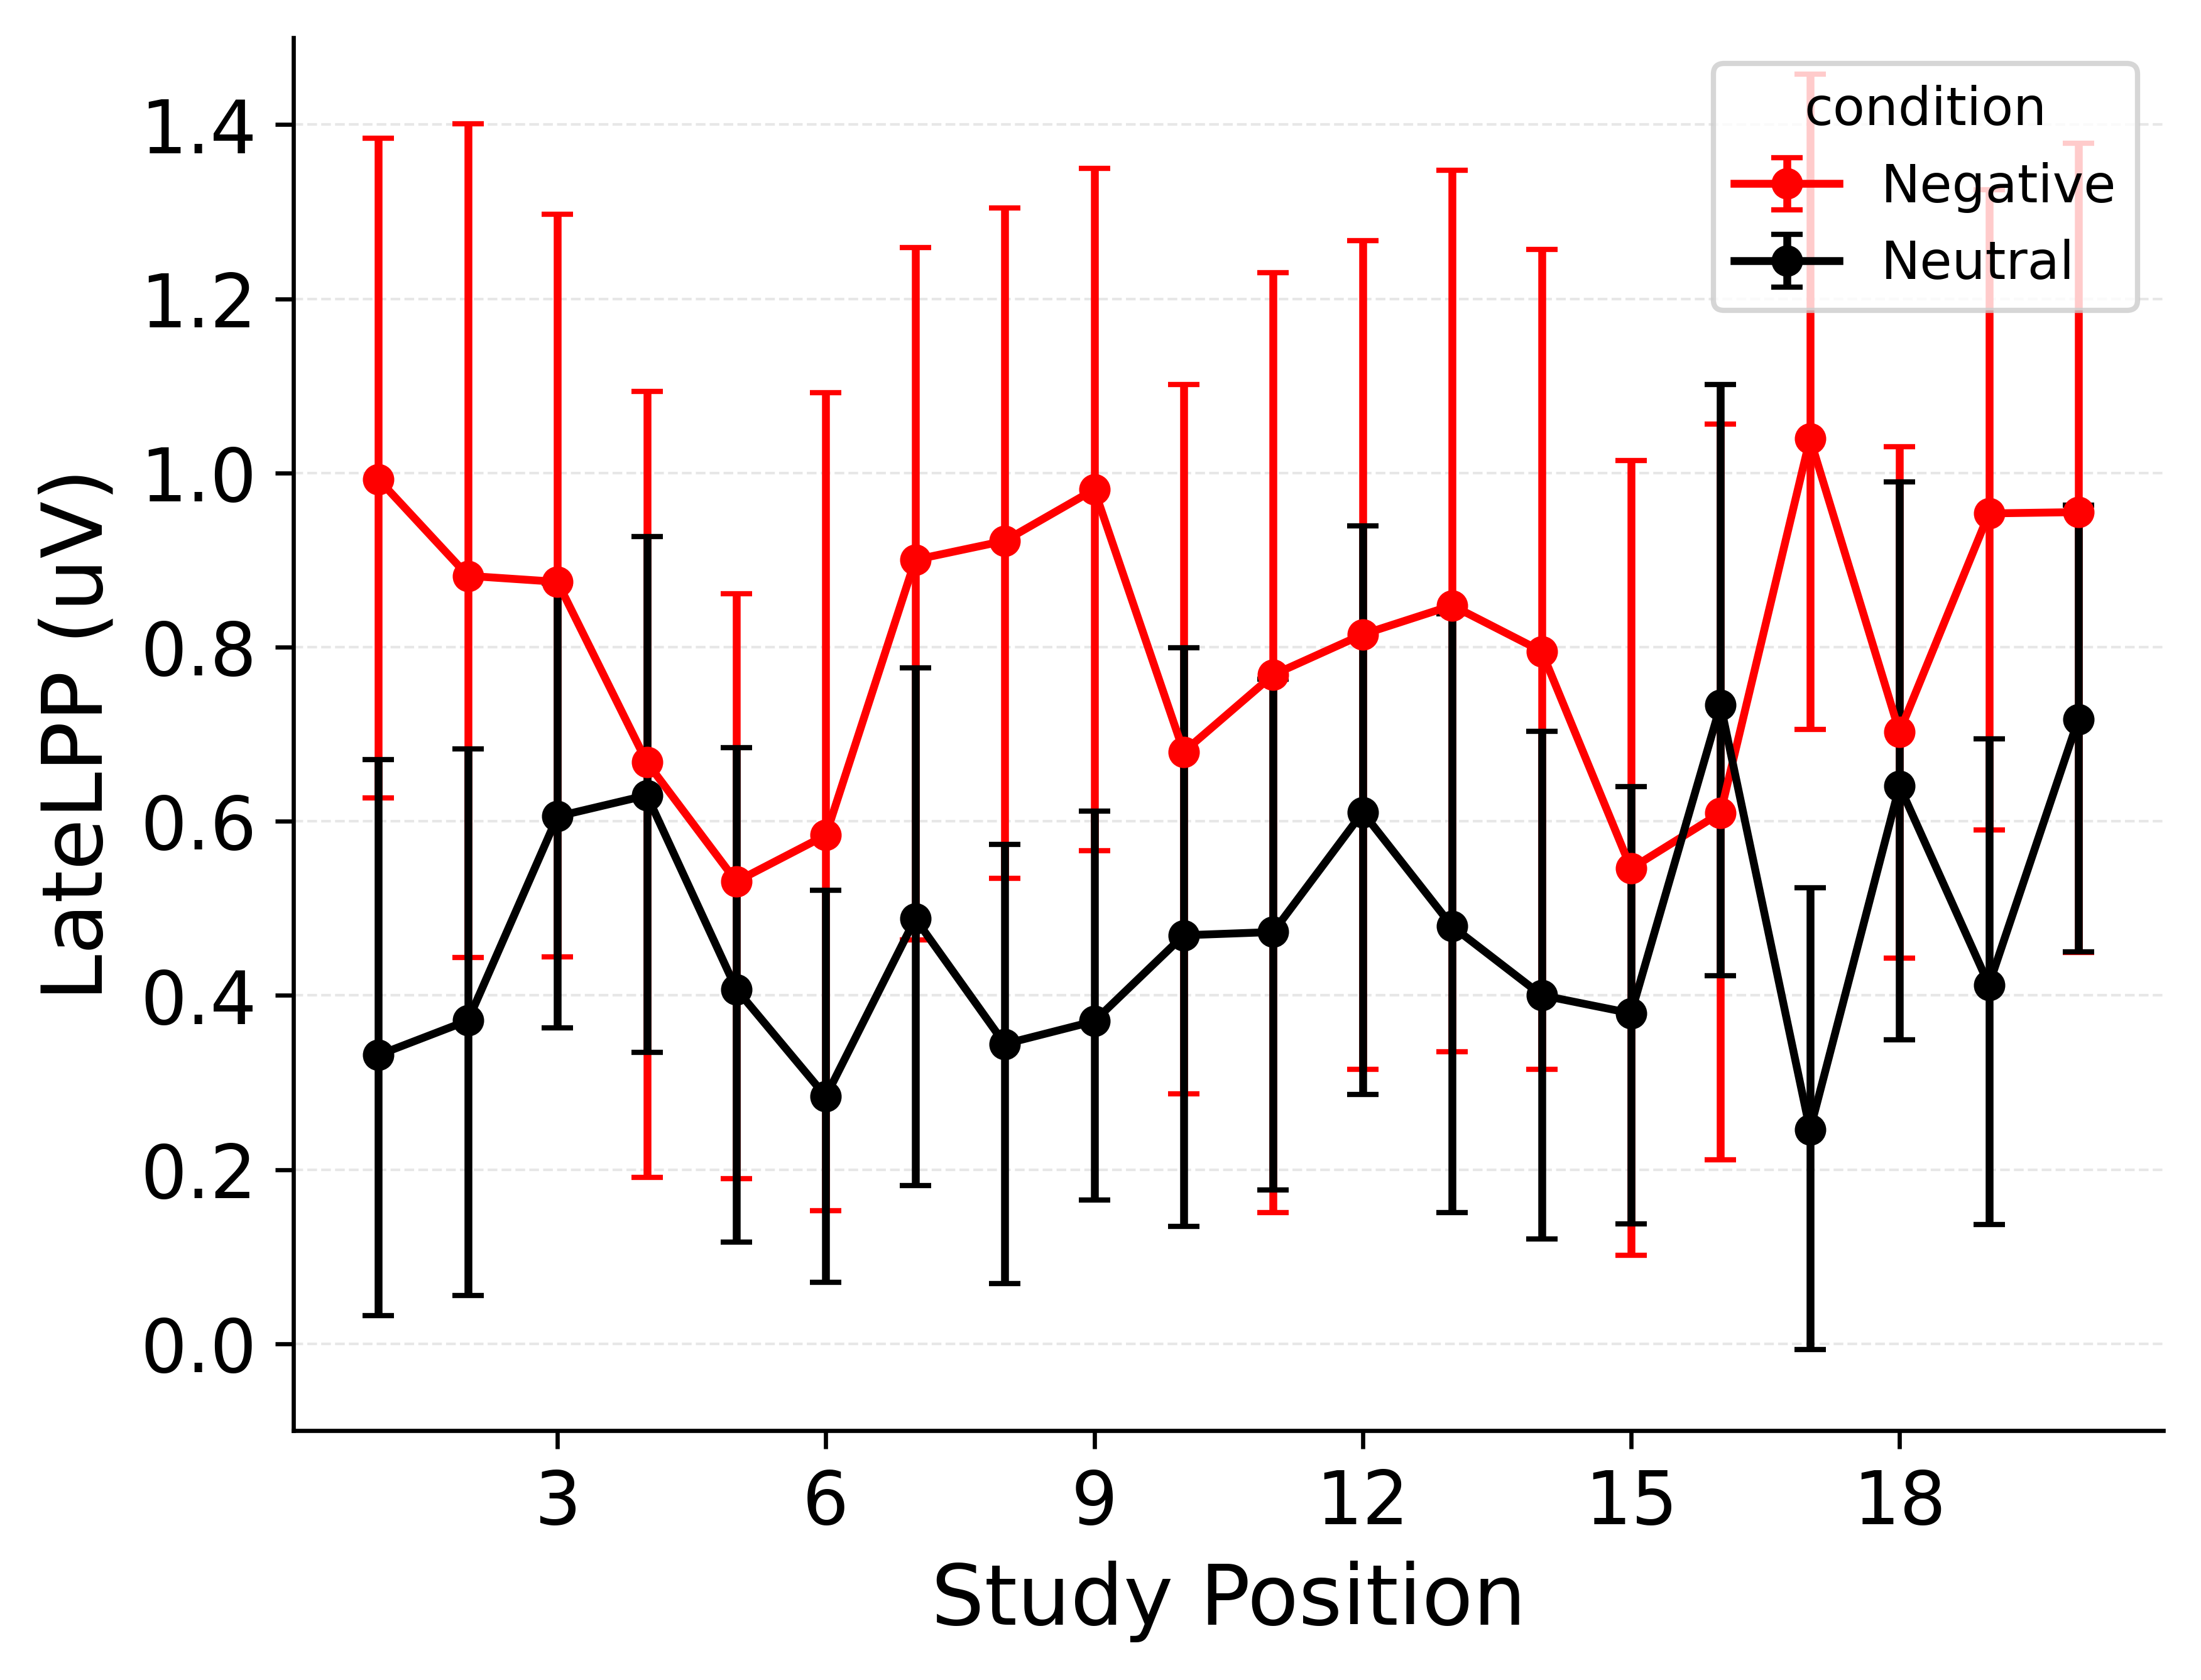

In [3]:
base_params = {
    "data_name": "TalmiEEG",
    "data_query": "data['subject'] > 0",
    "category_field": "condition",
    "category_values": [1, 2],
    "labels": ["Negative", "Neutral"],
    "color_cycle": ["red", "black"],
    "ylim": [-.1, 1.5],
    "output_path": "figures/analyses/cat_lpp_spc_{}.png",
}

for lpp_field in ["EarlyLPP", "LateLPP"]:
    output_path = base_params["output_path"].format(lpp_field)
    print(output_path)
    pm.execute_notebook(
        f"{find_project_root()}/analyses/templates/cat_lpp_spc.ipynb",
        f"{find_project_root()}/analyses/rendered/cat_lpp_spc_{lpp_field}.ipynb",
        parameters=base_params | {
            "lpp_field": lpp_field,
            "output_path": output_path,
        },
        progress_bar=False,
        prepare_only=True,
    )
    print(f"![]({output_path})")
    display(Image(filename=output_path, width=600))


# Categorized Recall Rate by LPP

Plot the recall rate as a function of binned LPP amplitude for different categories.


results/figures/analyses/cat_recall_by_lpp_EarlyLPP.png
![](results/figures/analyses/cat_recall_by_lpp_EarlyLPP.png)


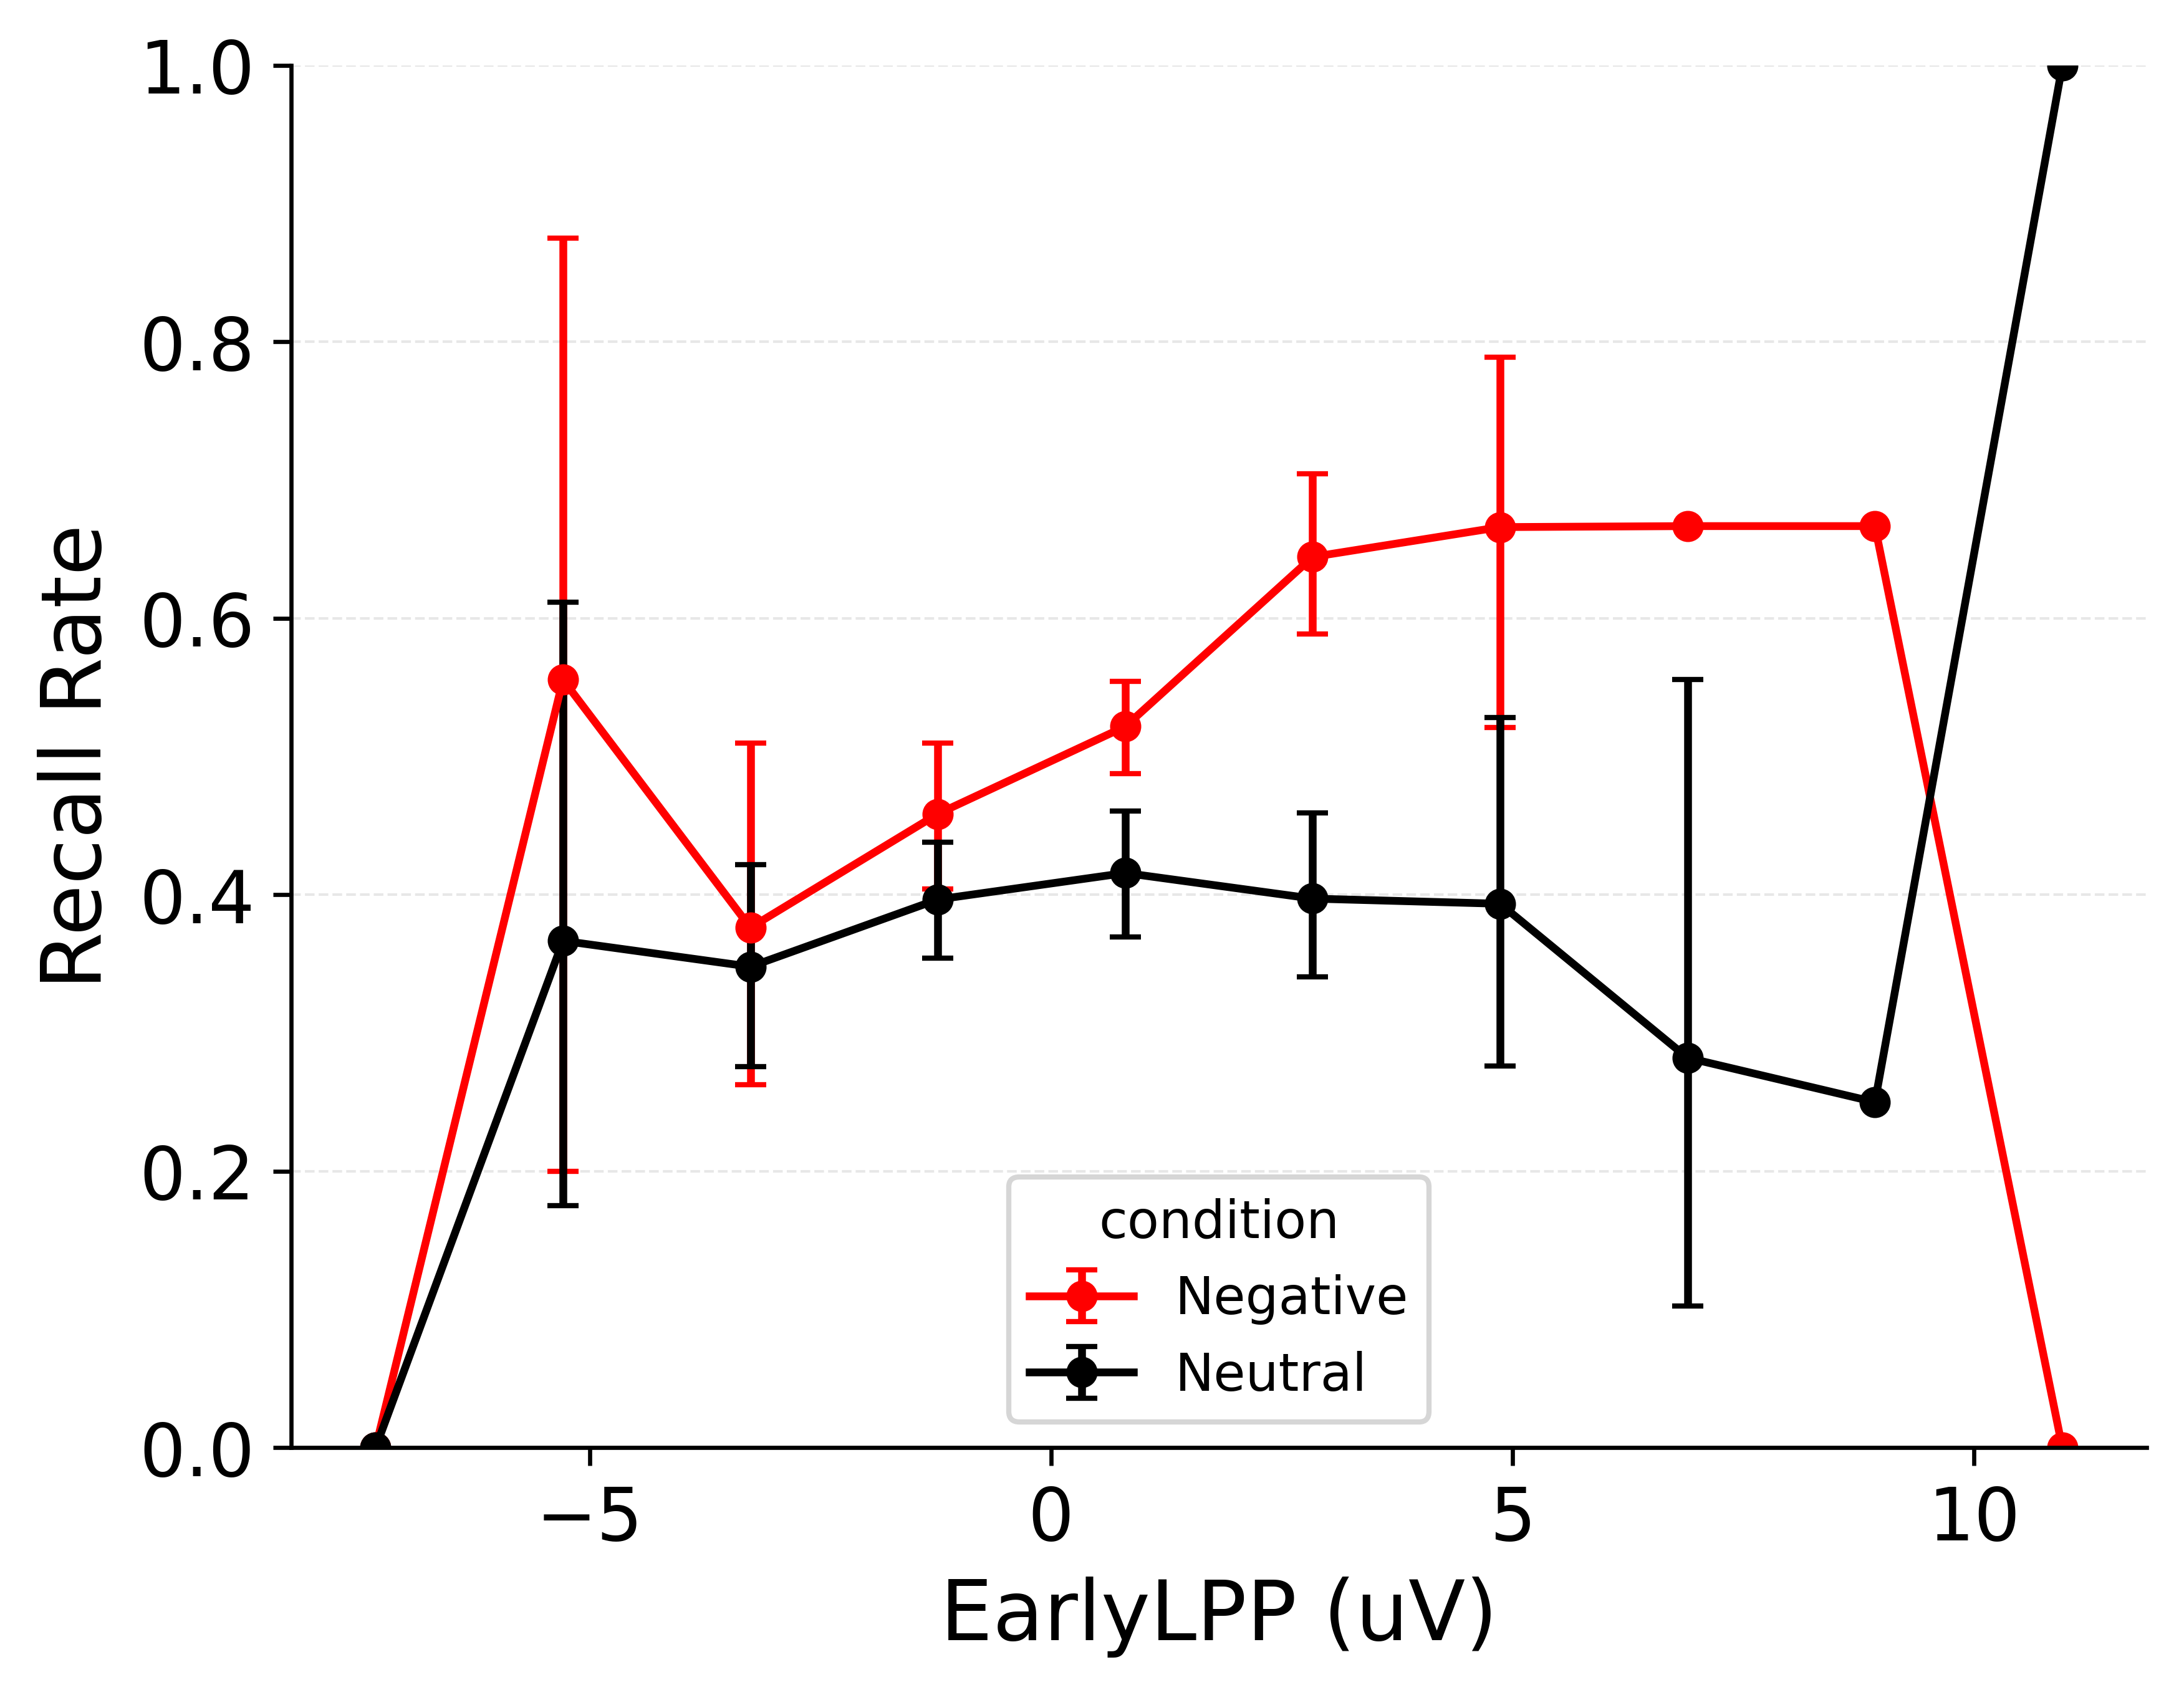

![](results/figures/analyses/cat_recall_by_lpp_EarlyLPP_counts.png)


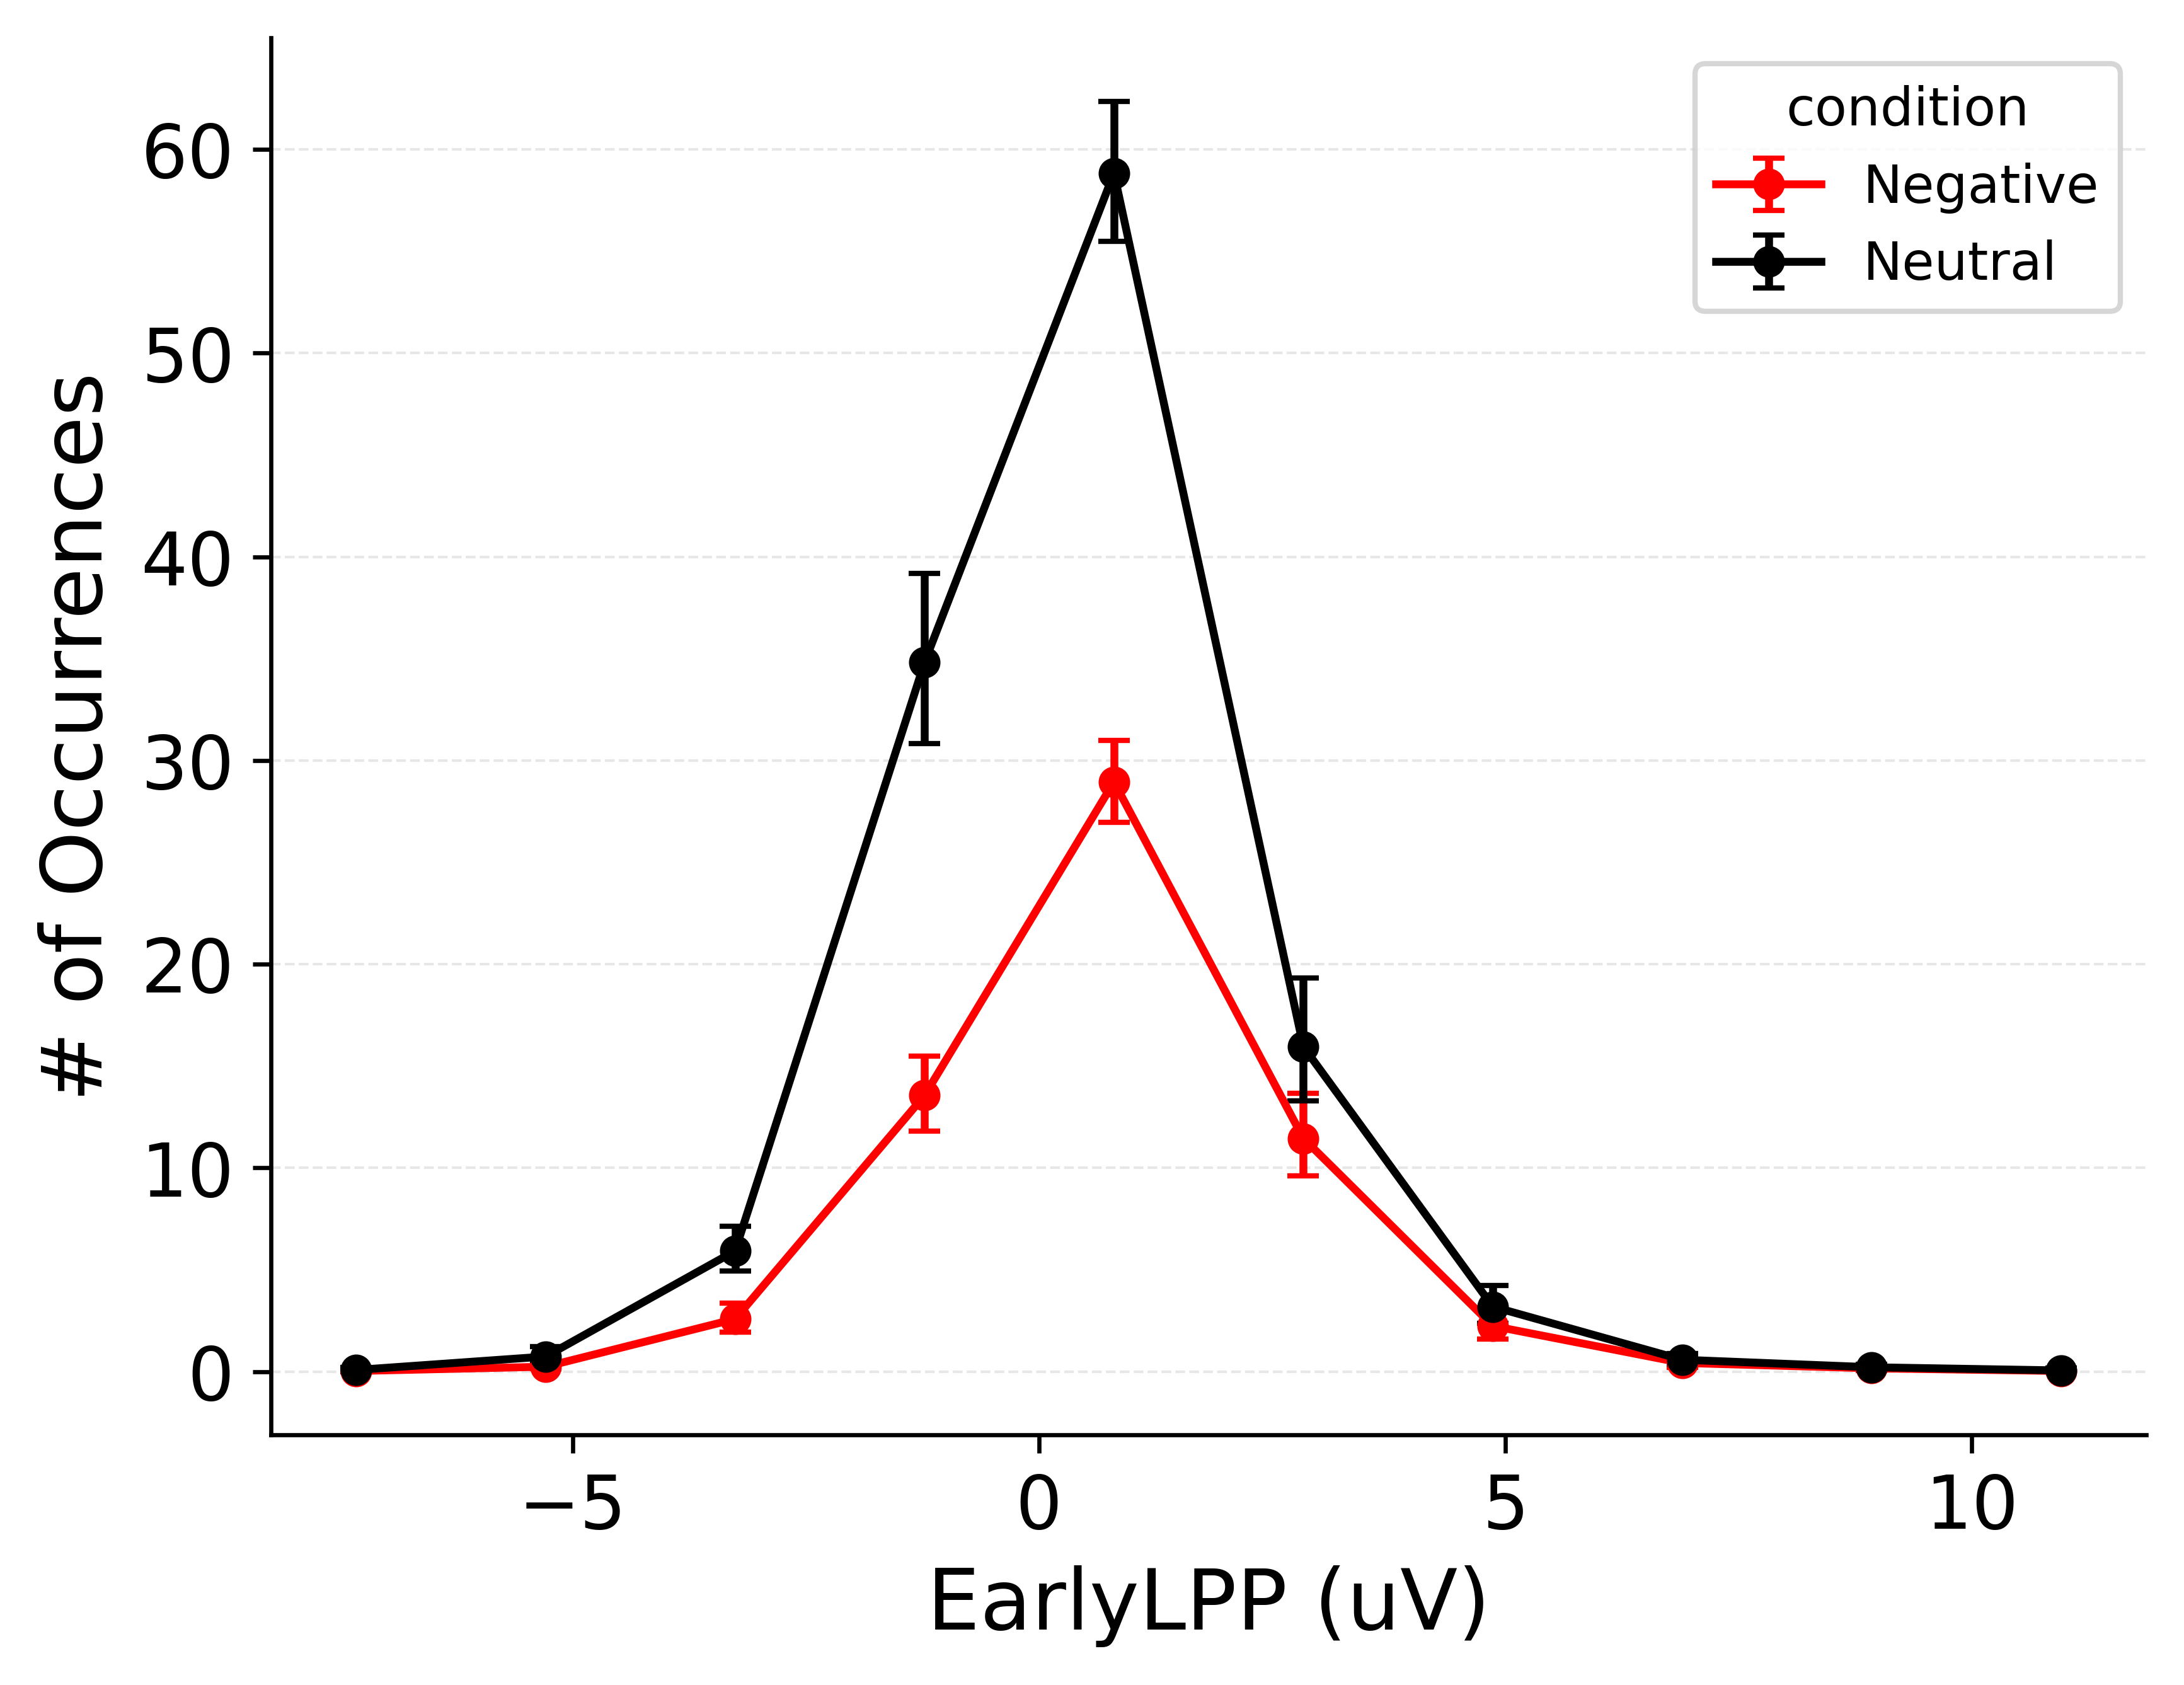

results/figures/analyses/cat_recall_by_lpp_LateLPP.png
![](results/figures/analyses/cat_recall_by_lpp_LateLPP.png)


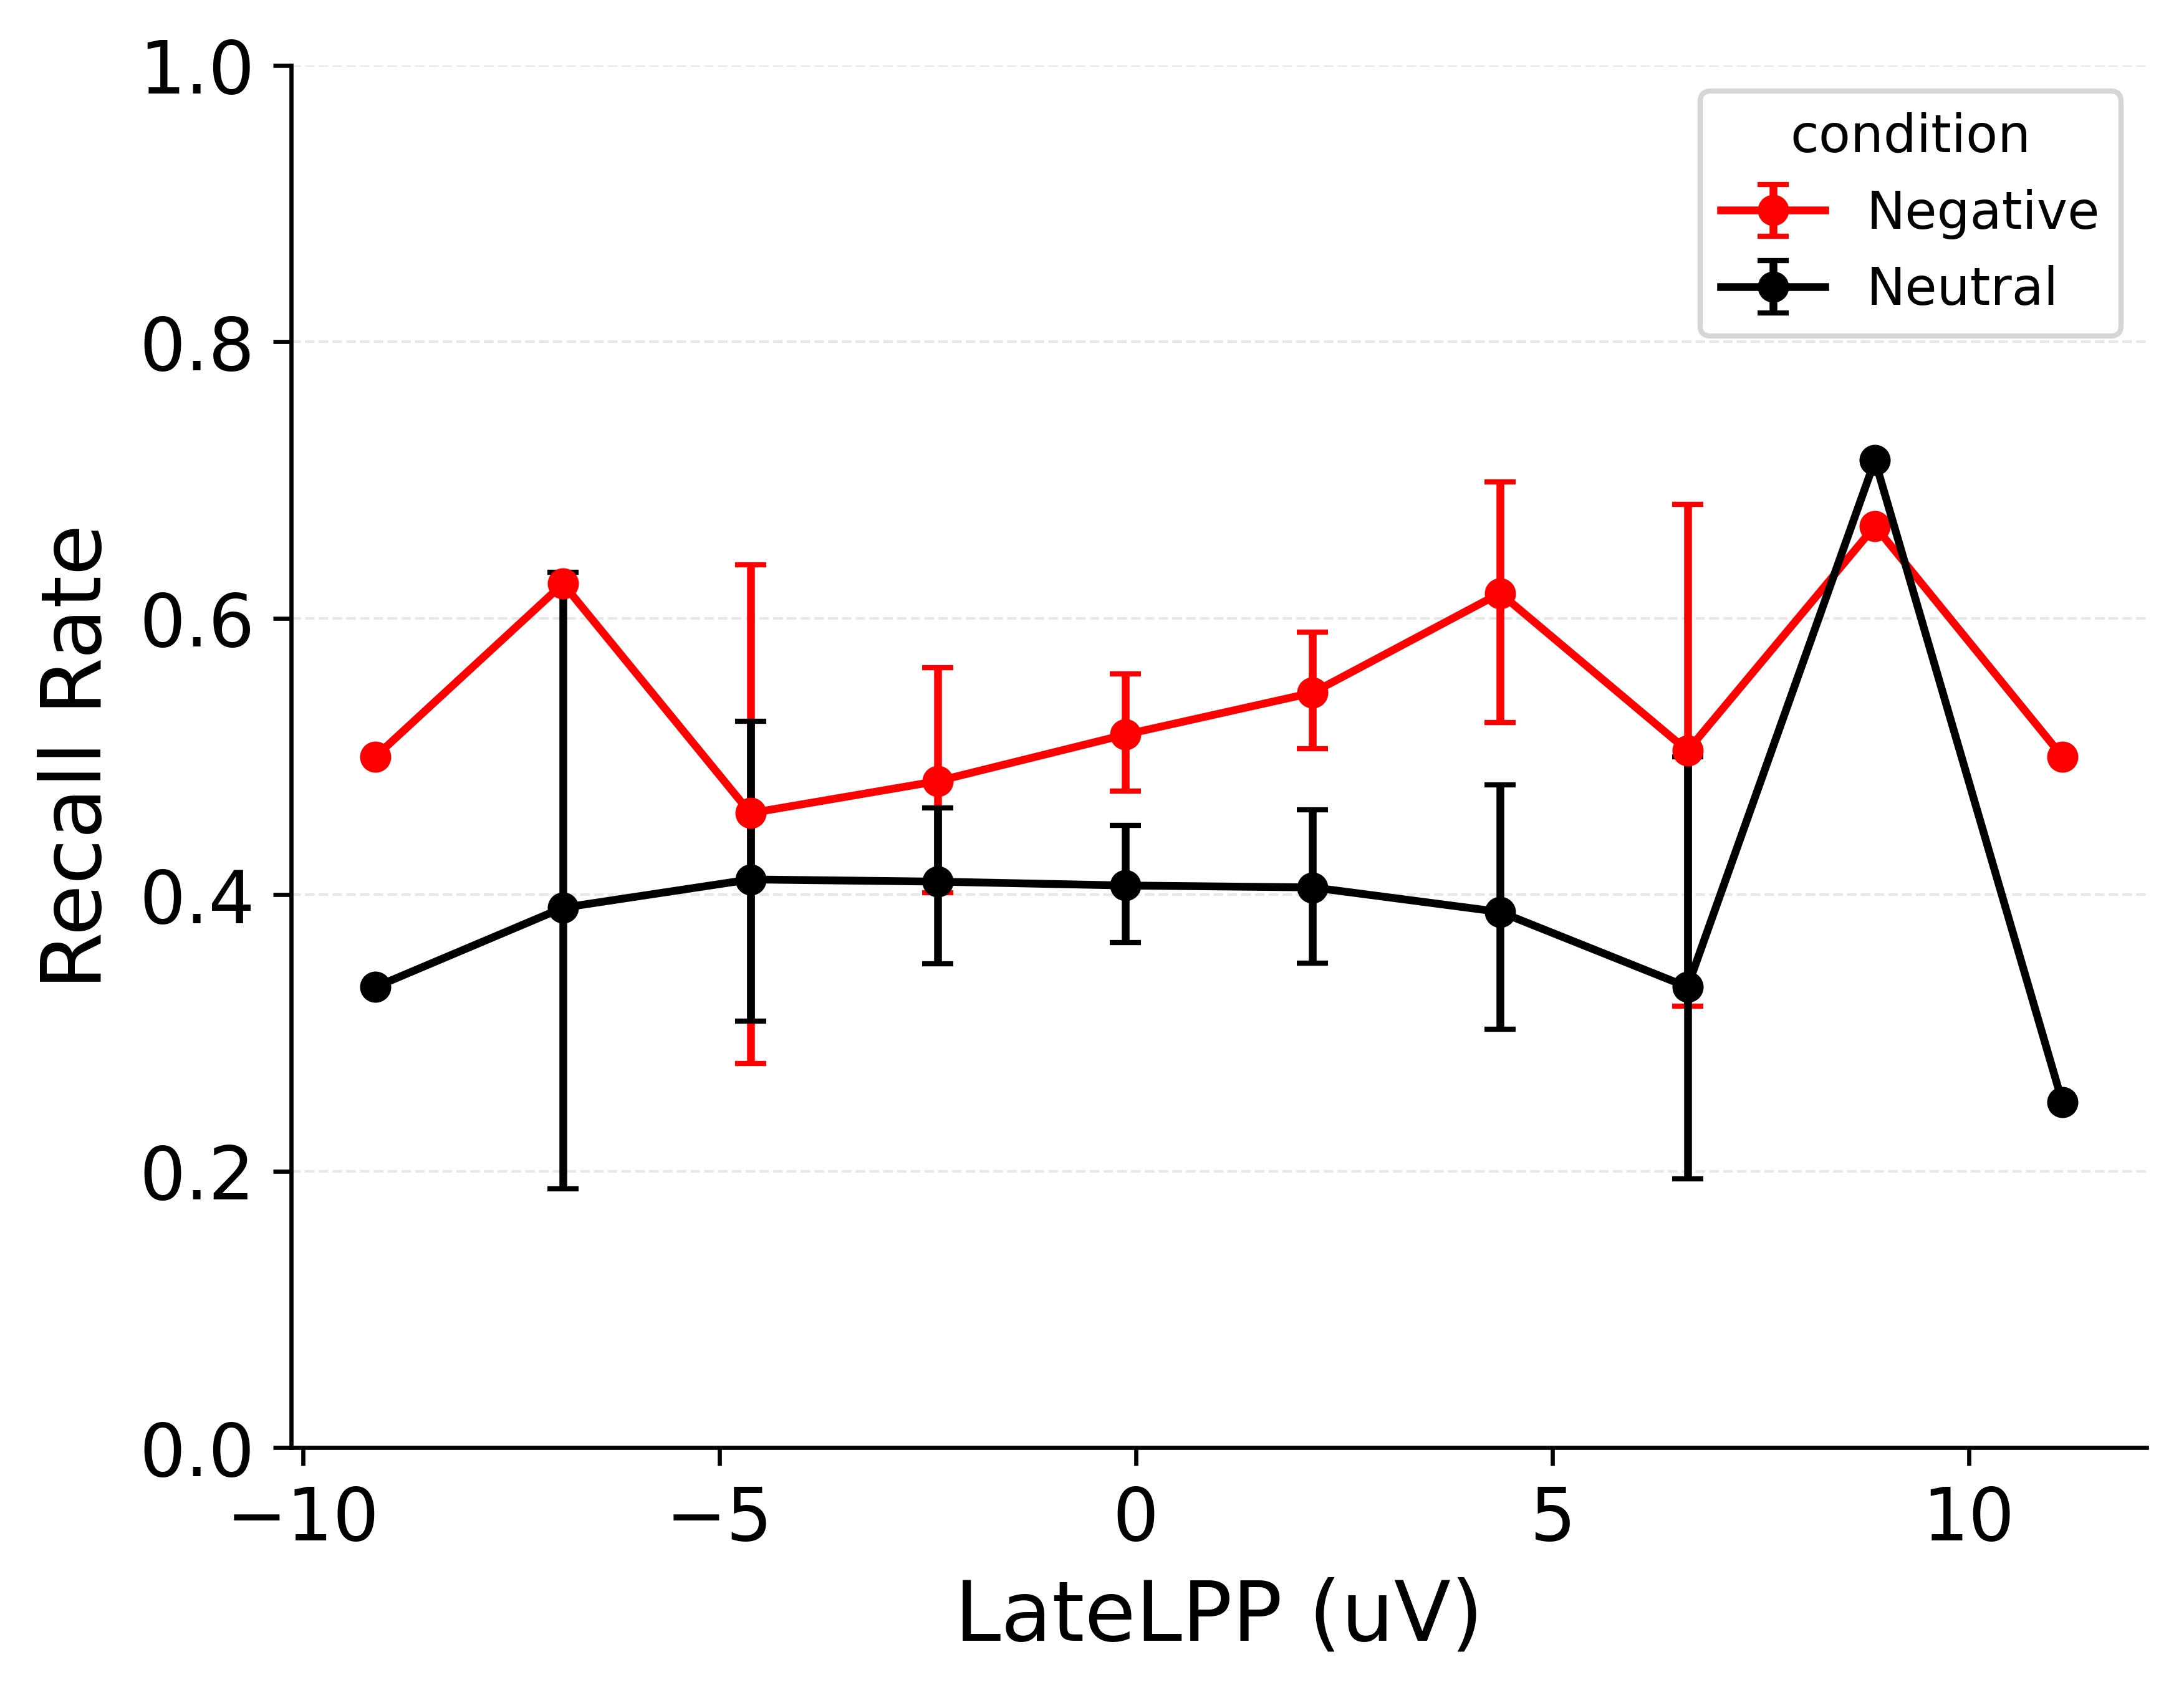

![](results/figures/analyses/cat_recall_by_lpp_LateLPP_counts.png)


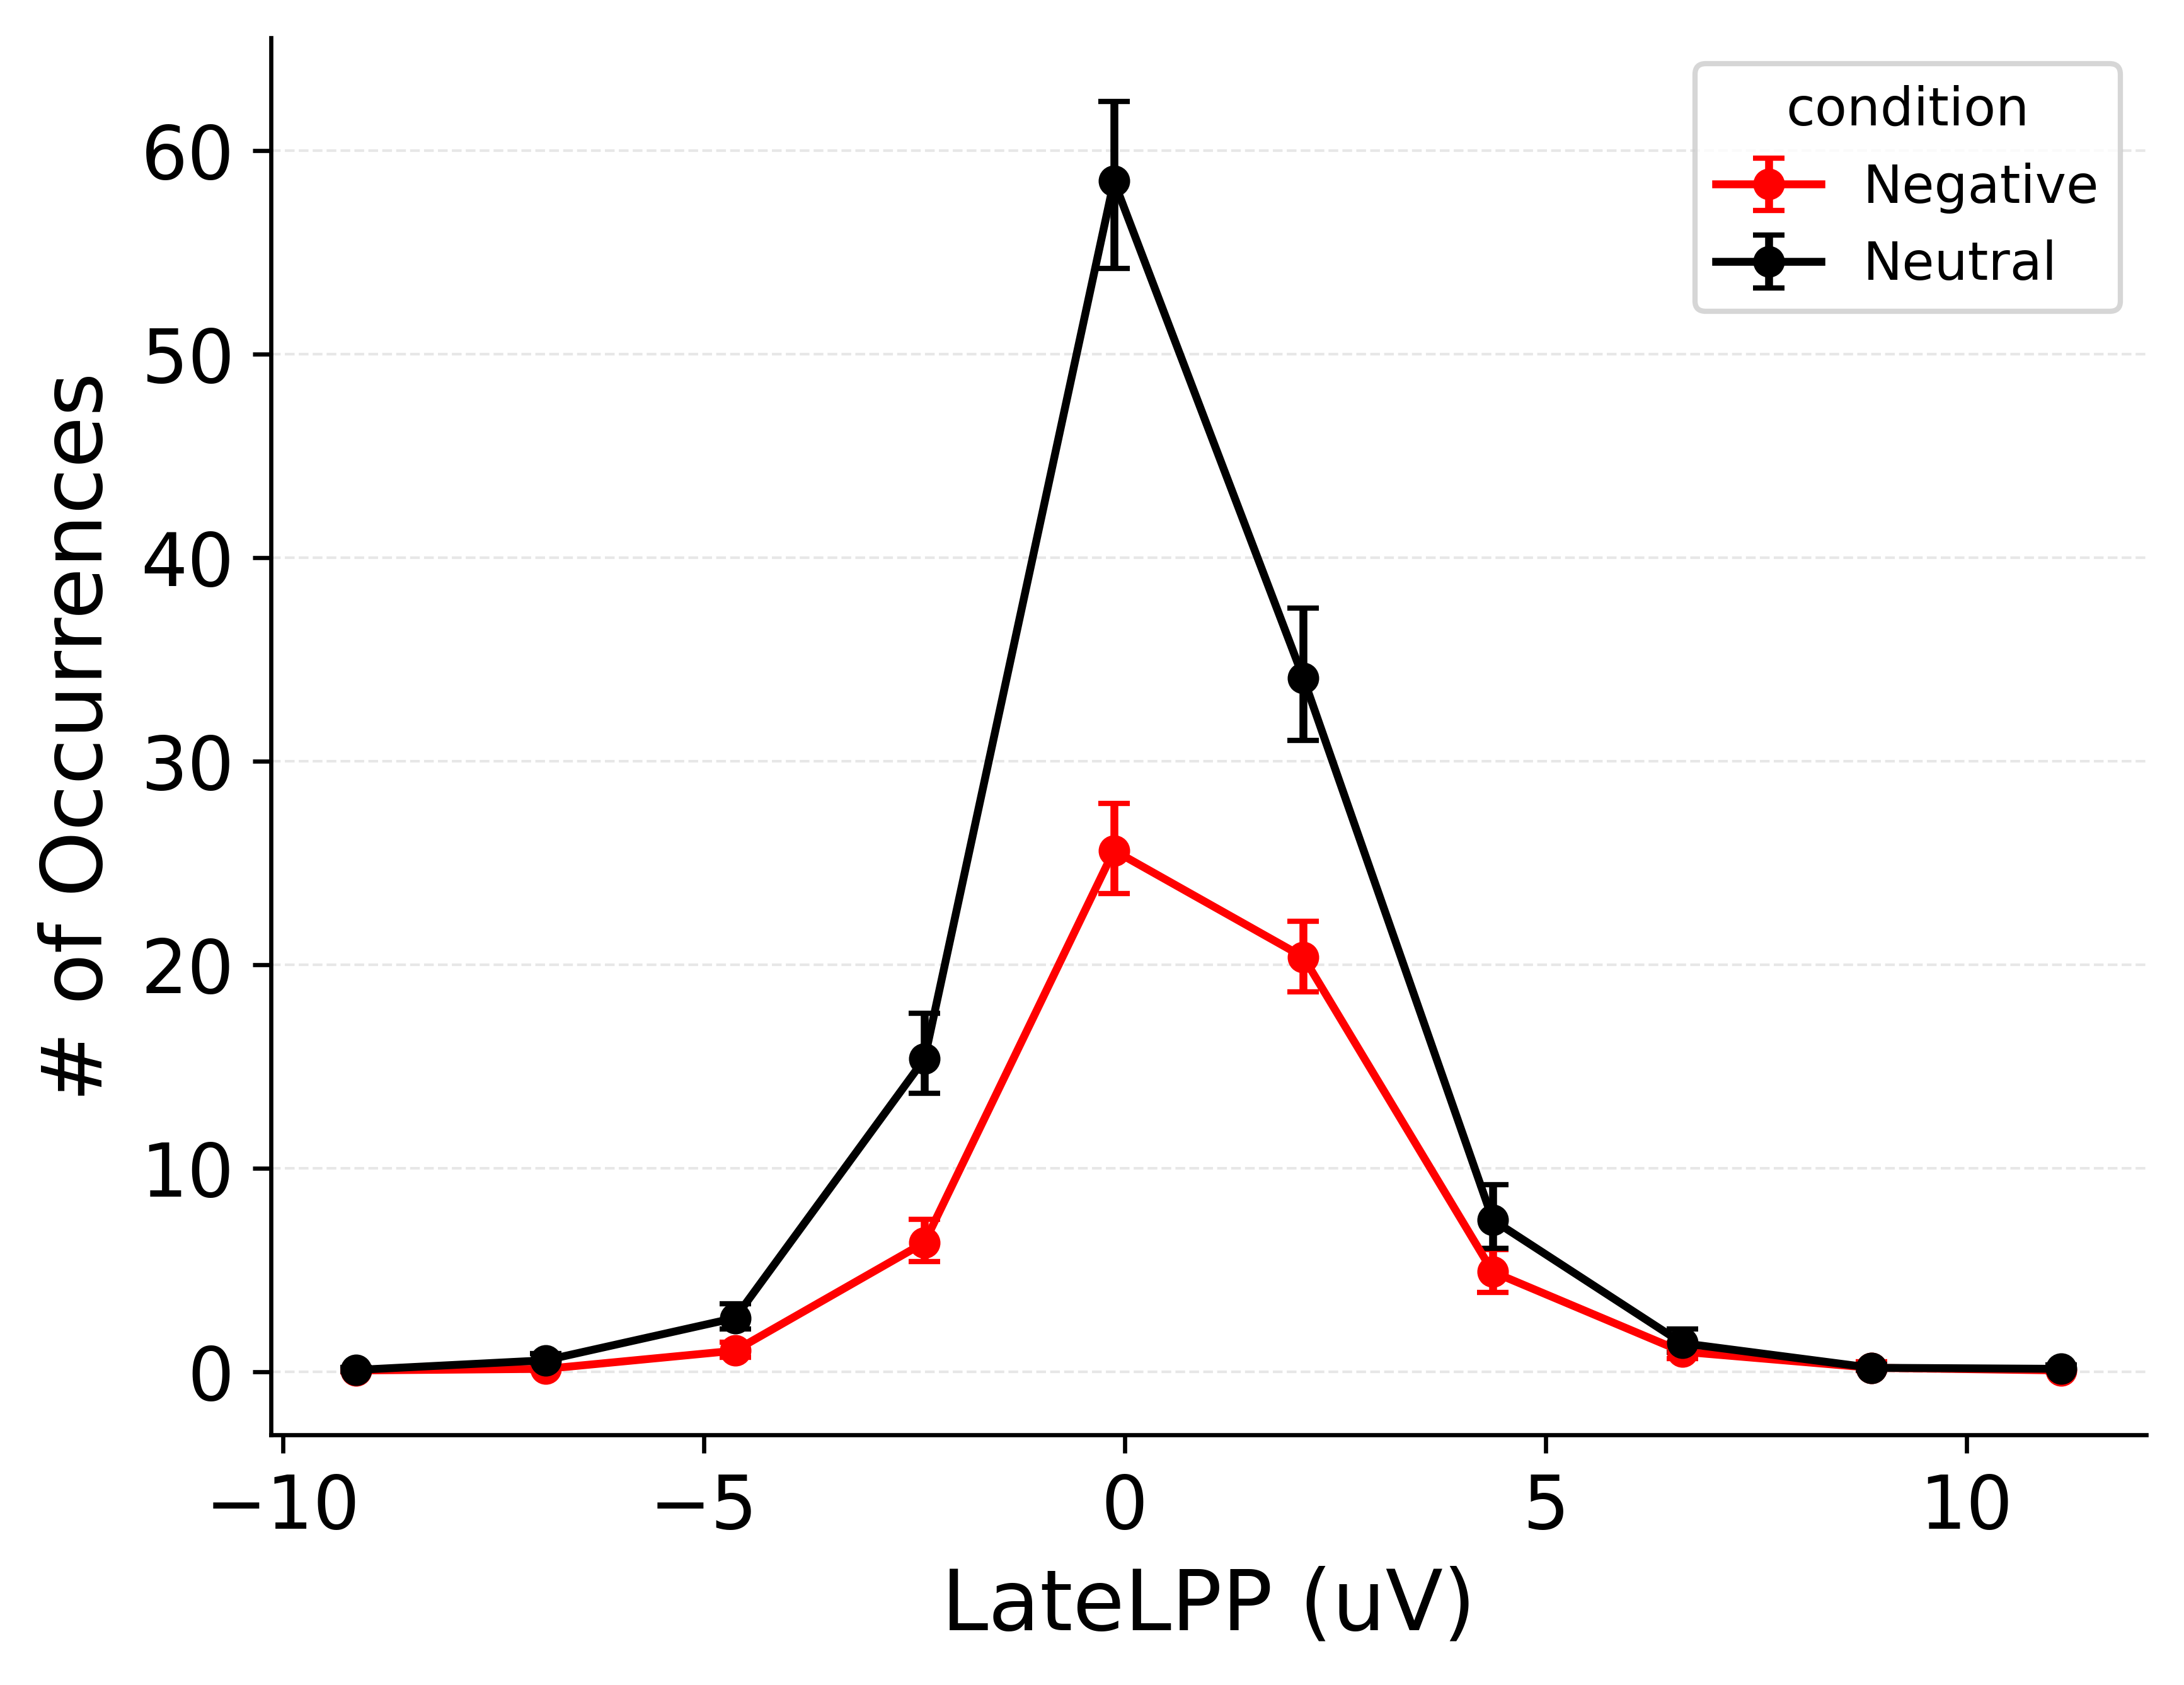

In [4]:
base_params = {
    "data_name": "TalmiEEG",
    "data_query": "data['subject'] > 0",
    "category_field": "condition",
    "category_values": [1, 2],
    "labels": ["Negative", "Neutral"],
    "color_cycle": ["red", "black"],
    "ylim": [0, 1.0],
    "output_path": "figures/analyses/cat_recall_by_lpp_{}.png",
}

for lpp_field in ["EarlyLPP", "LateLPP"]:
    output_path = base_params["output_path"].format(lpp_field)
    print(output_path)
    pm.execute_notebook(
        f"{find_project_root()}/analyses/templates/cat_recall_by_lpp.ipynb",
        f"{find_project_root()}/analyses/rendered/cat_recall_by_lpp_{lpp_field}.ipynb",
        parameters=base_params | {
            "lpp_field": lpp_field,
            "output_path": output_path,
        },
        progress_bar=False,
        prepare_only=True,
    )
    print(f"![]({output_path})")
    display(Image(filename=output_path, width=600))

    print(f"![]({output_path.replace('.png', '_counts.png')})")
    display(Image(filename=output_path.replace(".png", "_counts.png"), width=600))


# Categorized LPP by Recall Status
Plot the LPP amplitudes for items of a given category, separated by whether they were later recalled or not.

![](results/figures/analyses/cat_lpp_by_recall_EarlyLPP_Negative.png)


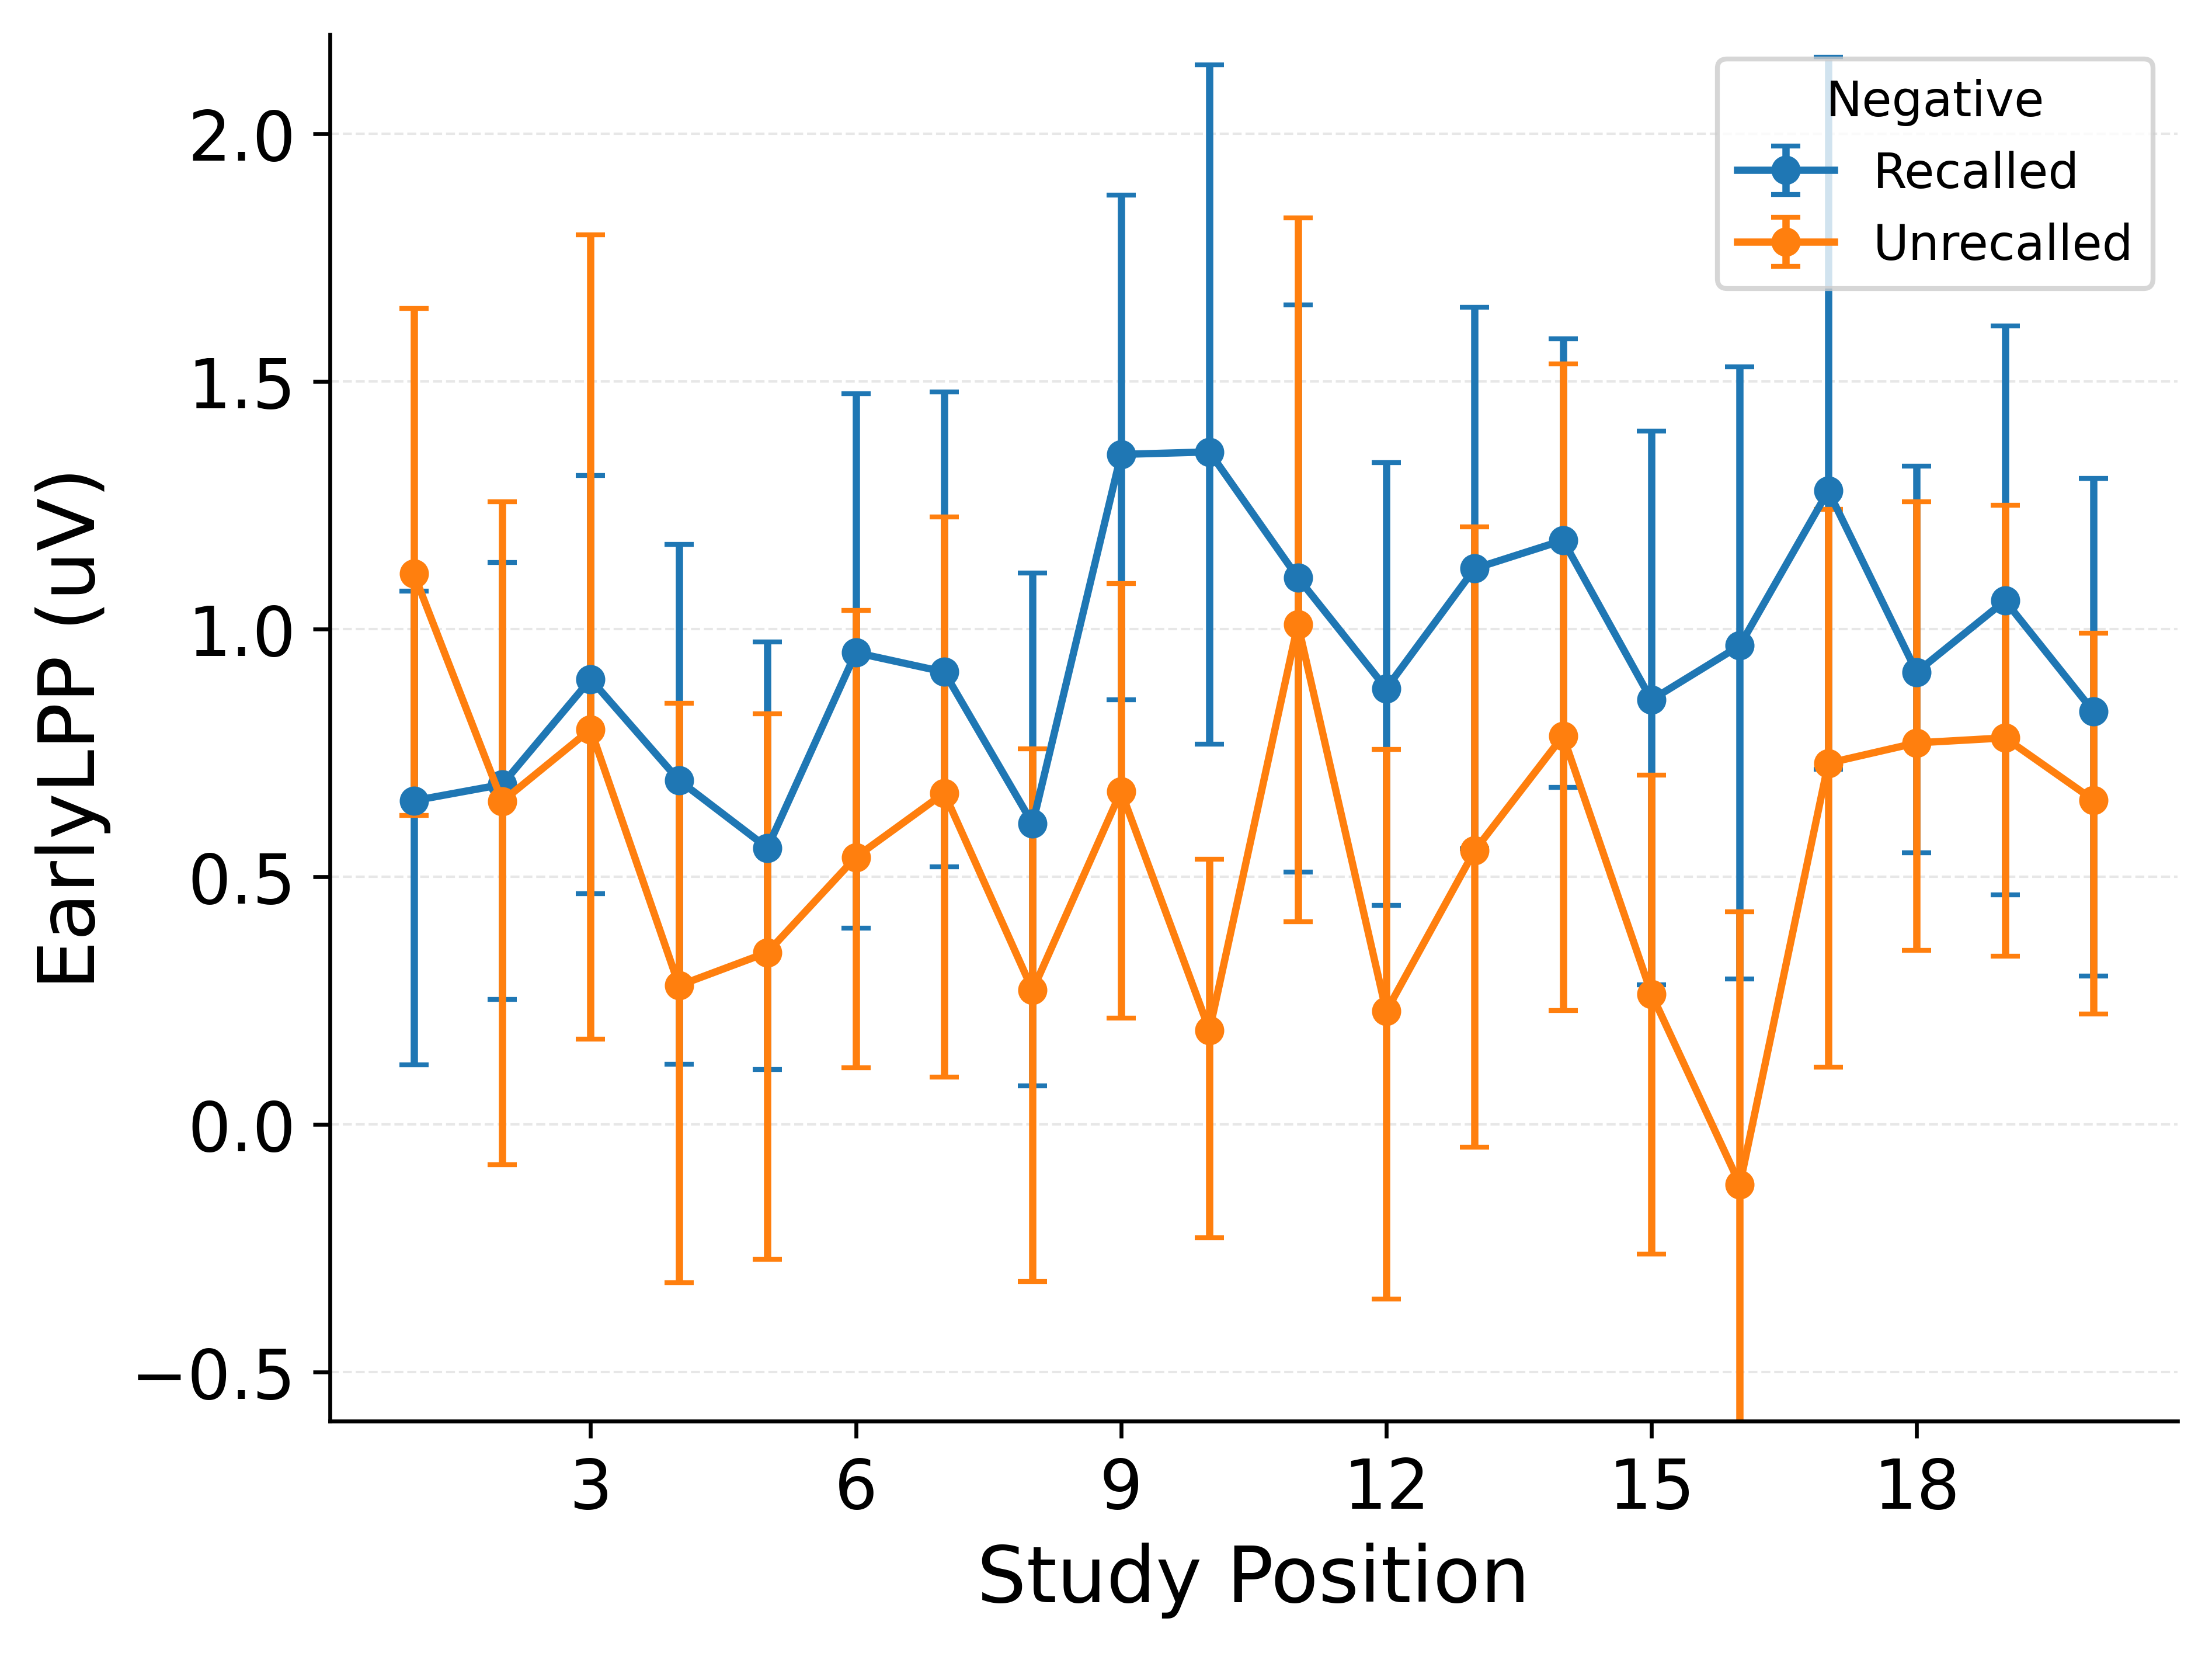

![](results/figures/analyses/cat_lpp_by_recall_EarlyLPP_Neutral.png)


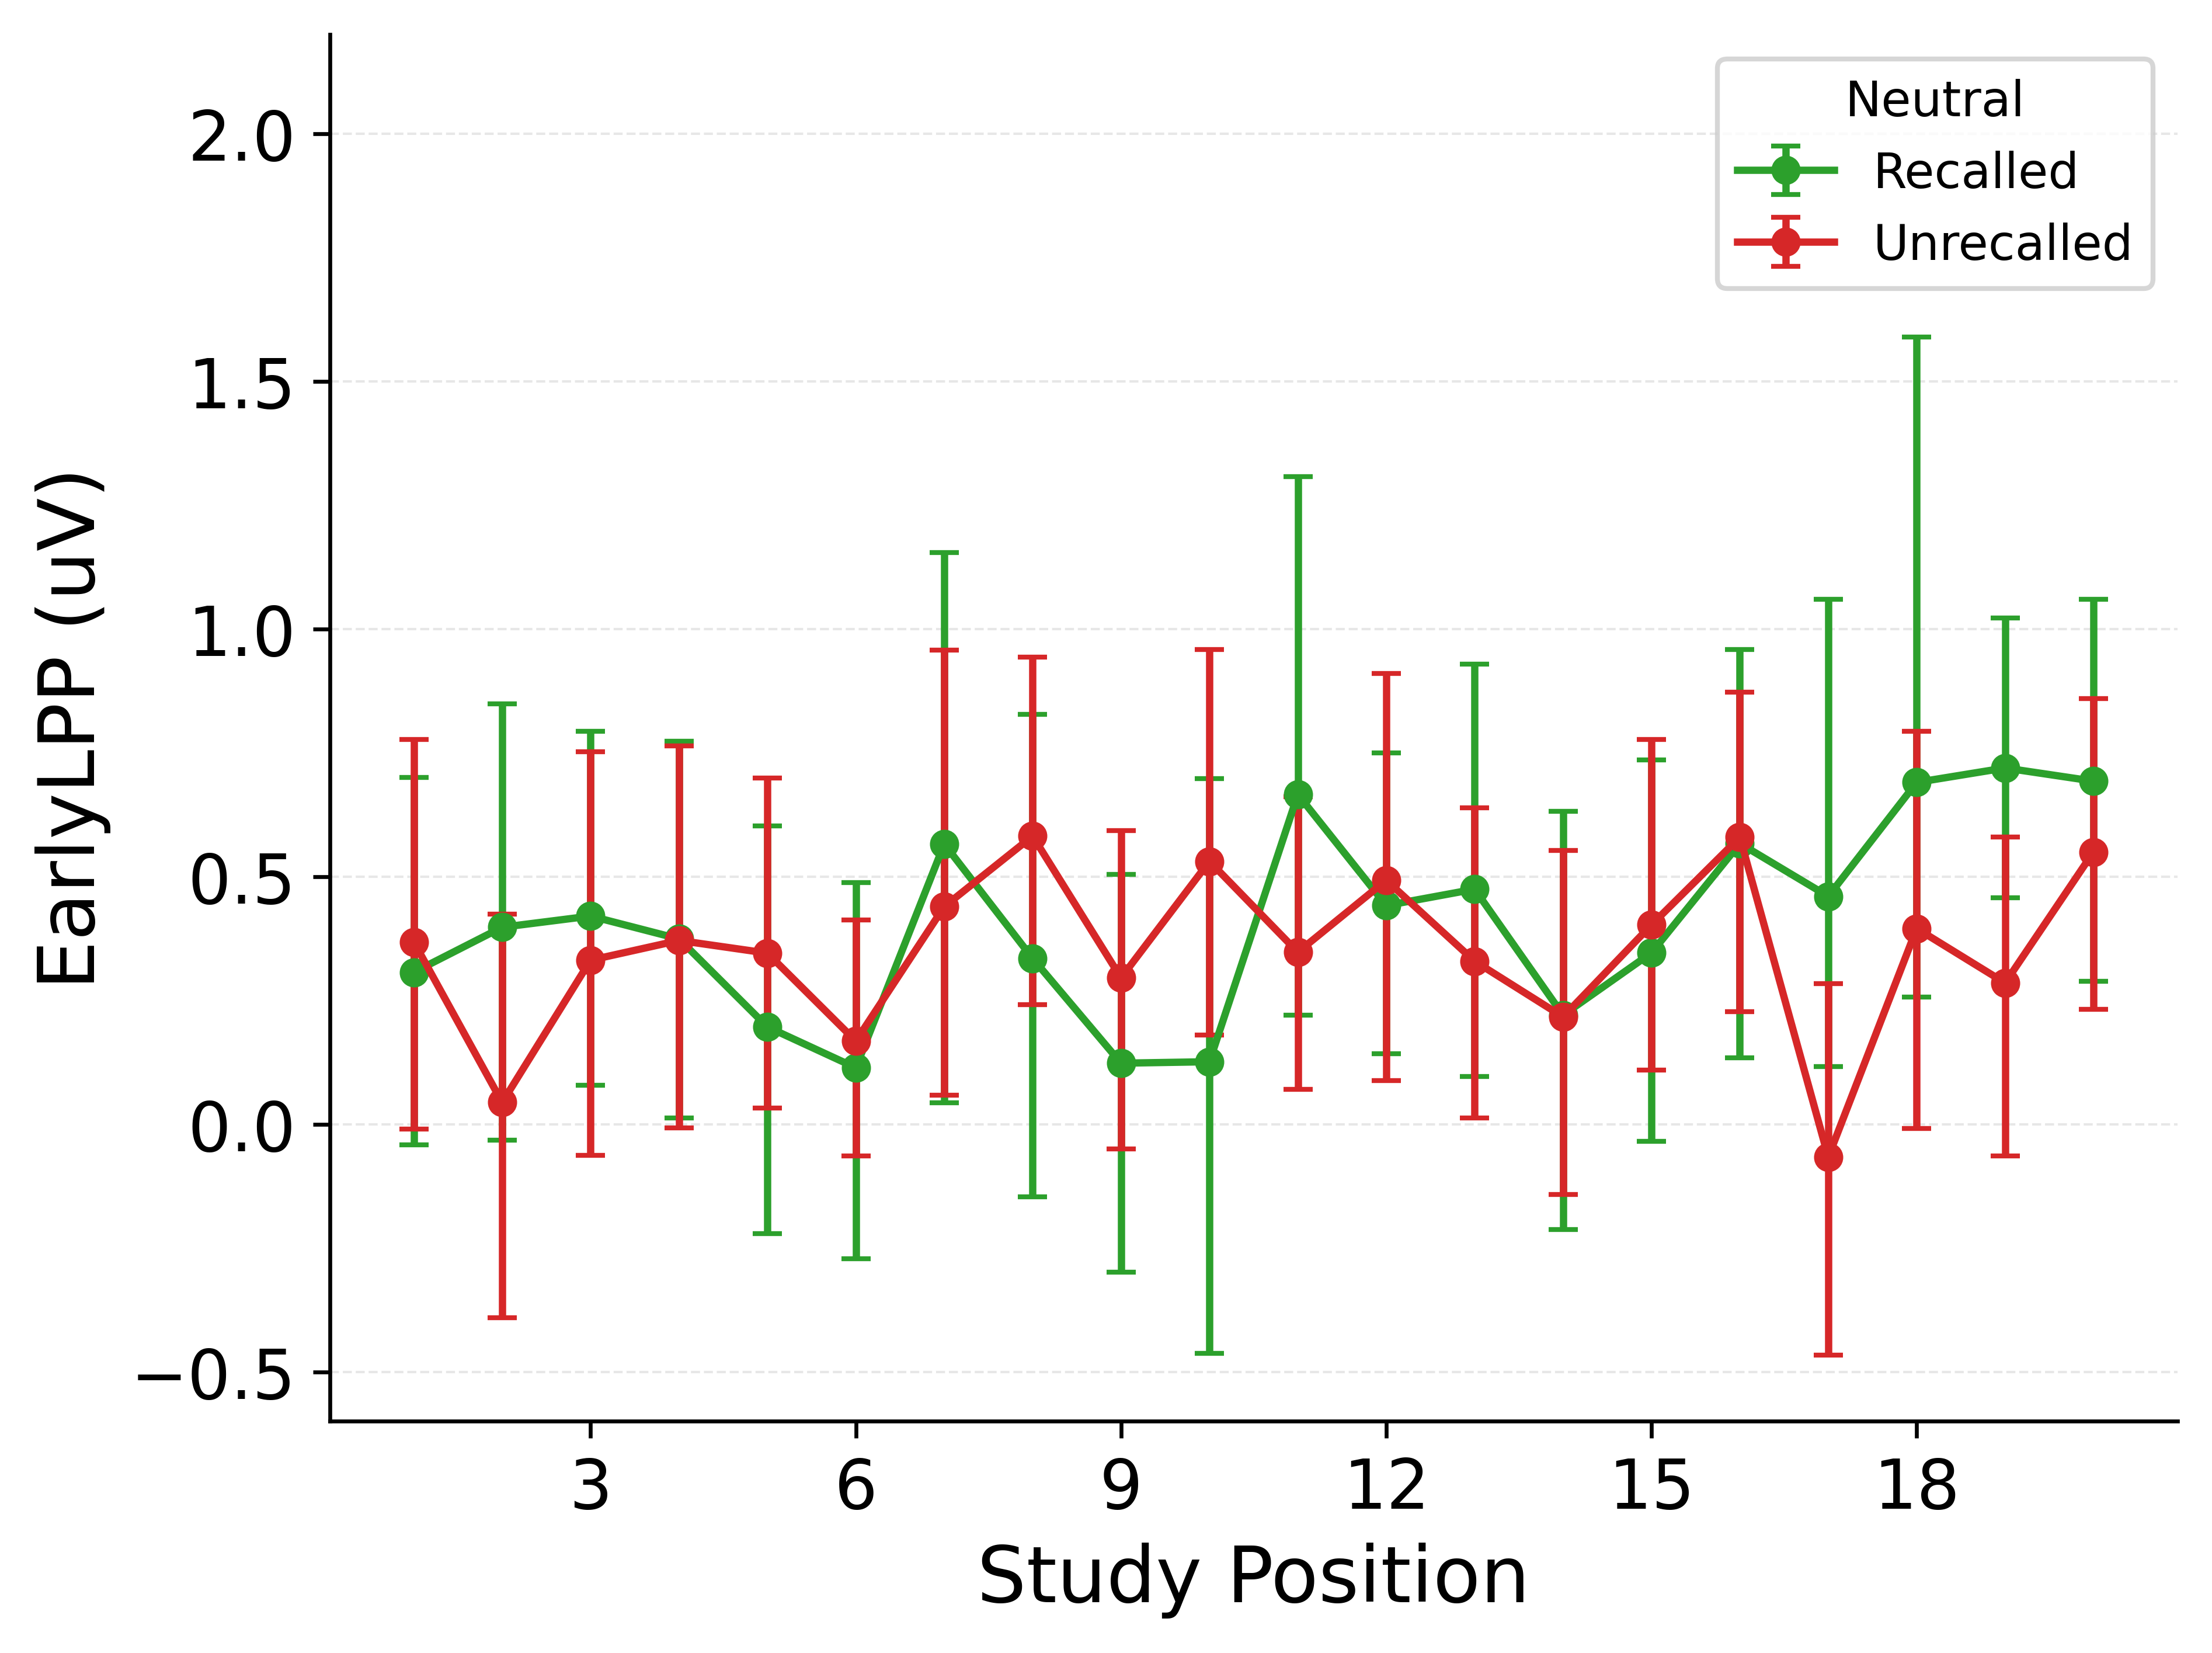

![](results/figures/analyses/cat_lpp_by_recall_LateLPP_Negative.png)


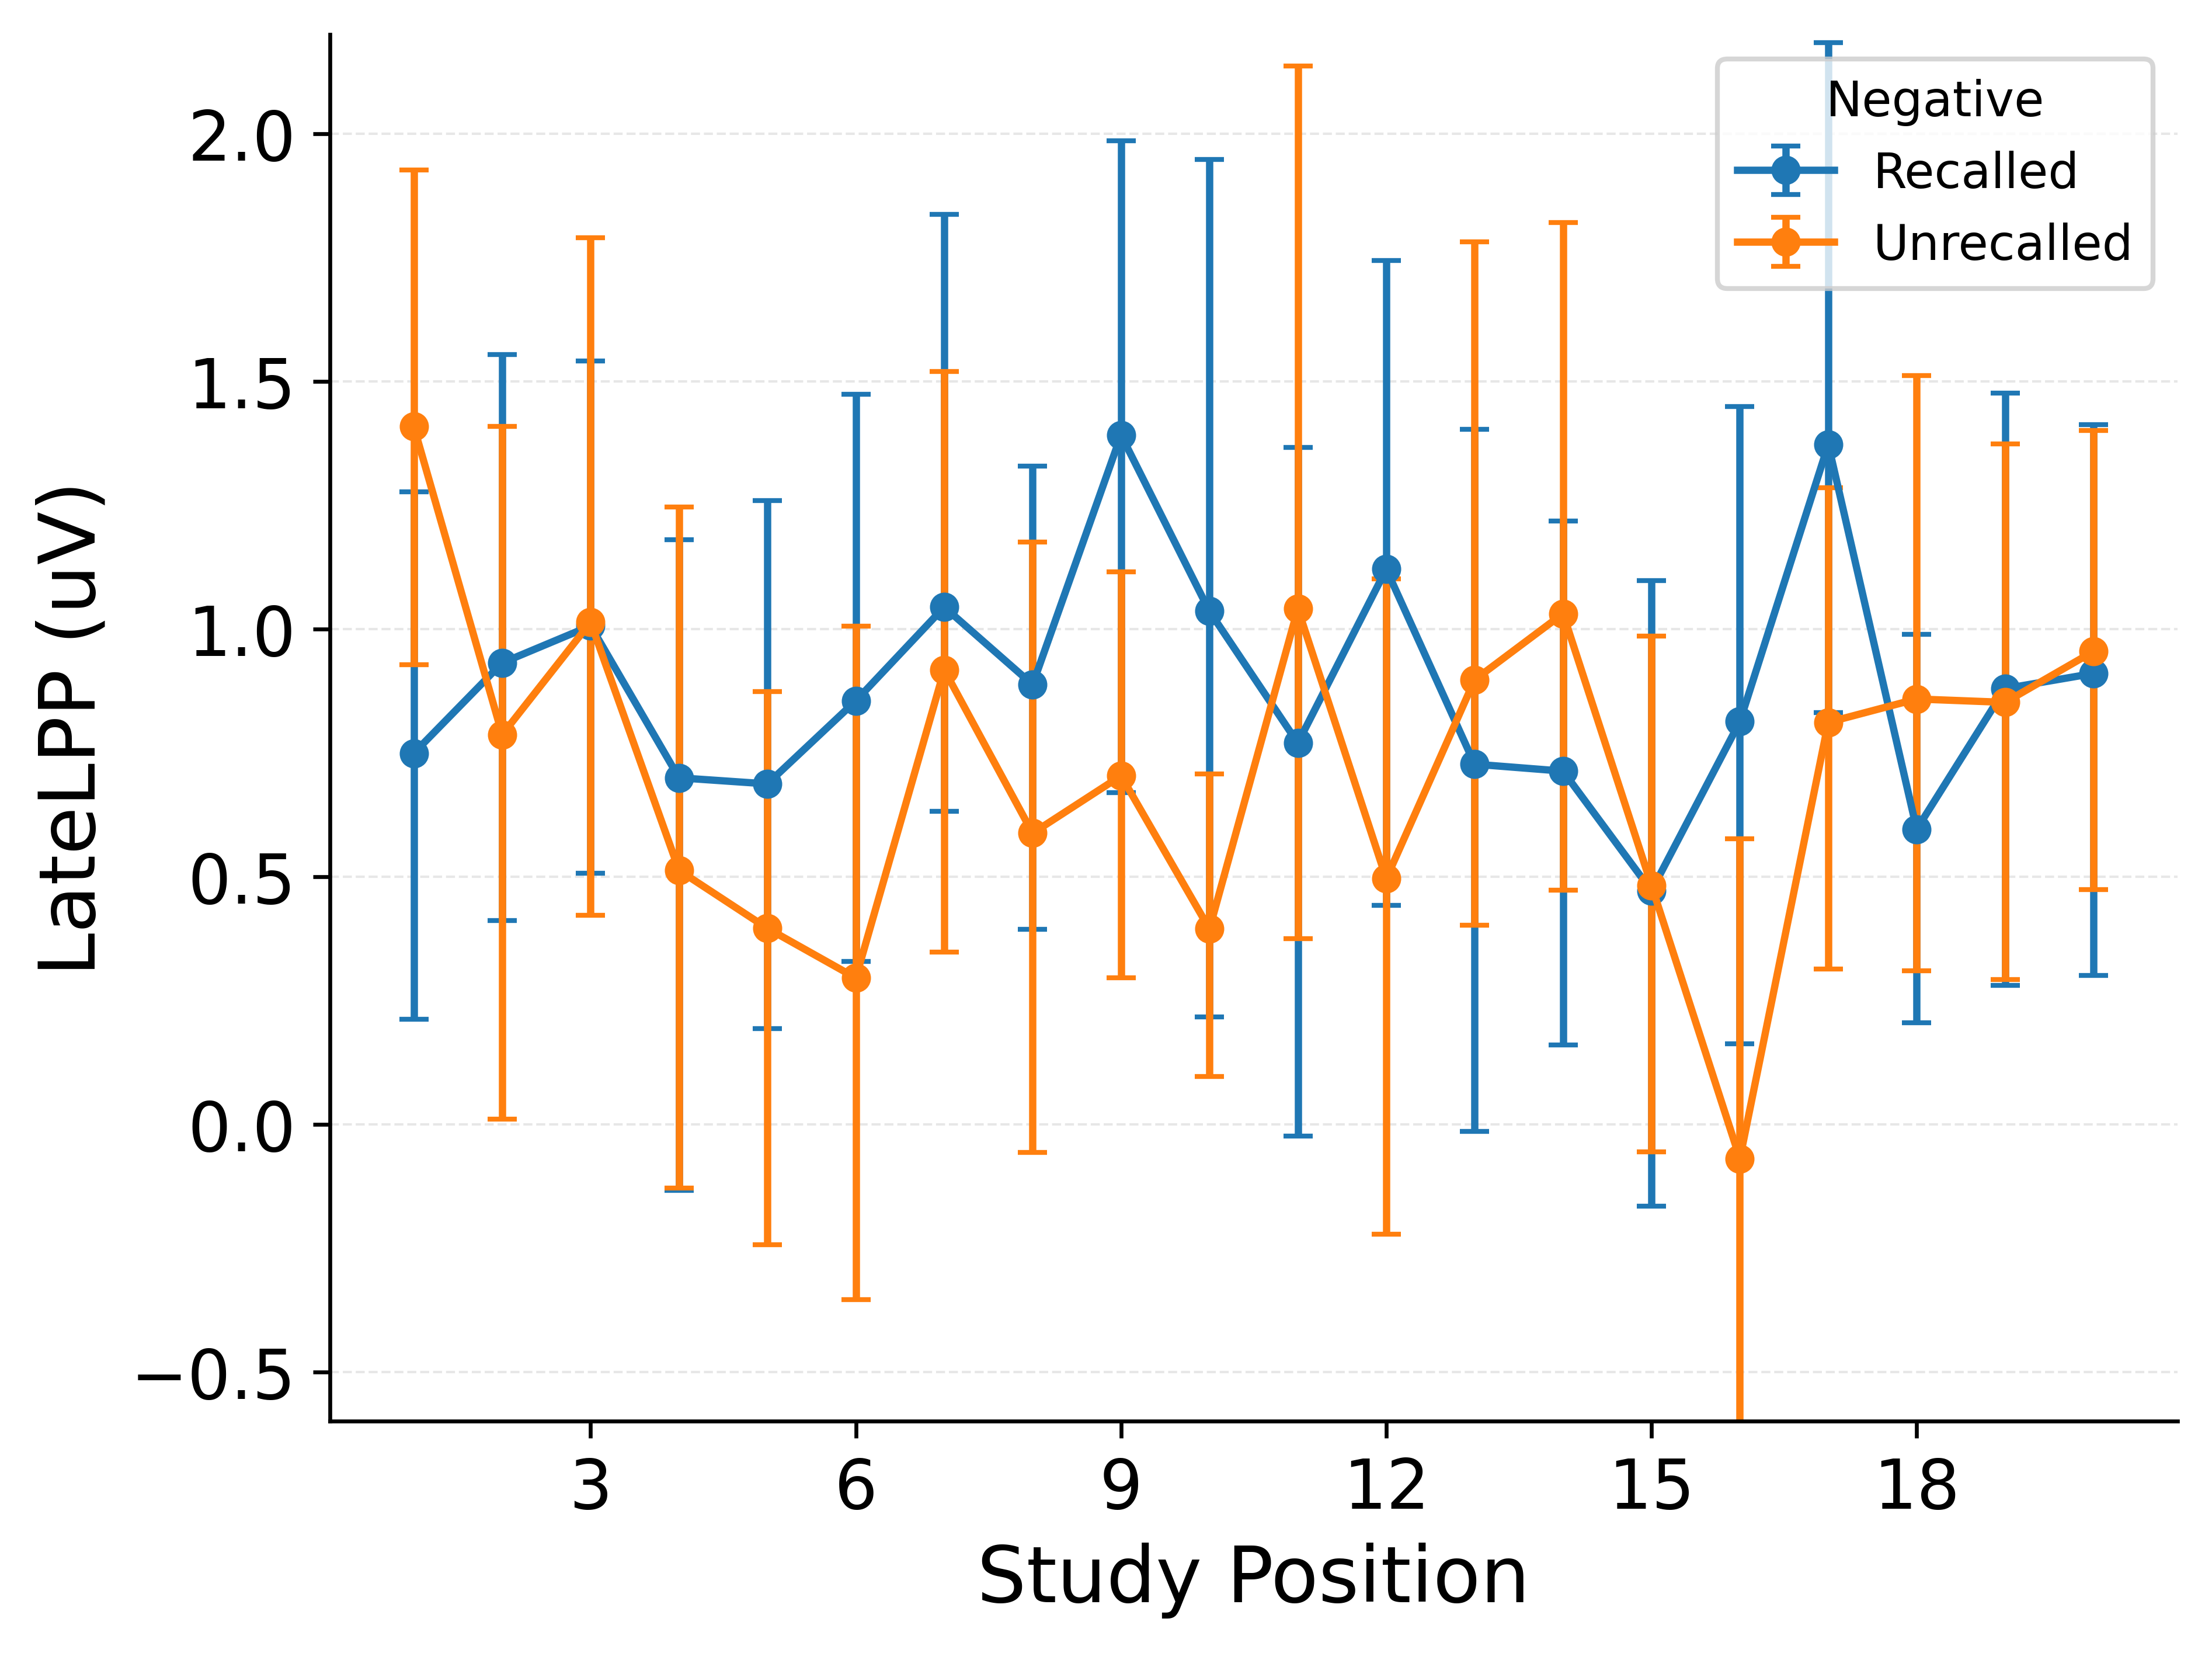

![](results/figures/analyses/cat_lpp_by_recall_LateLPP_Neutral.png)


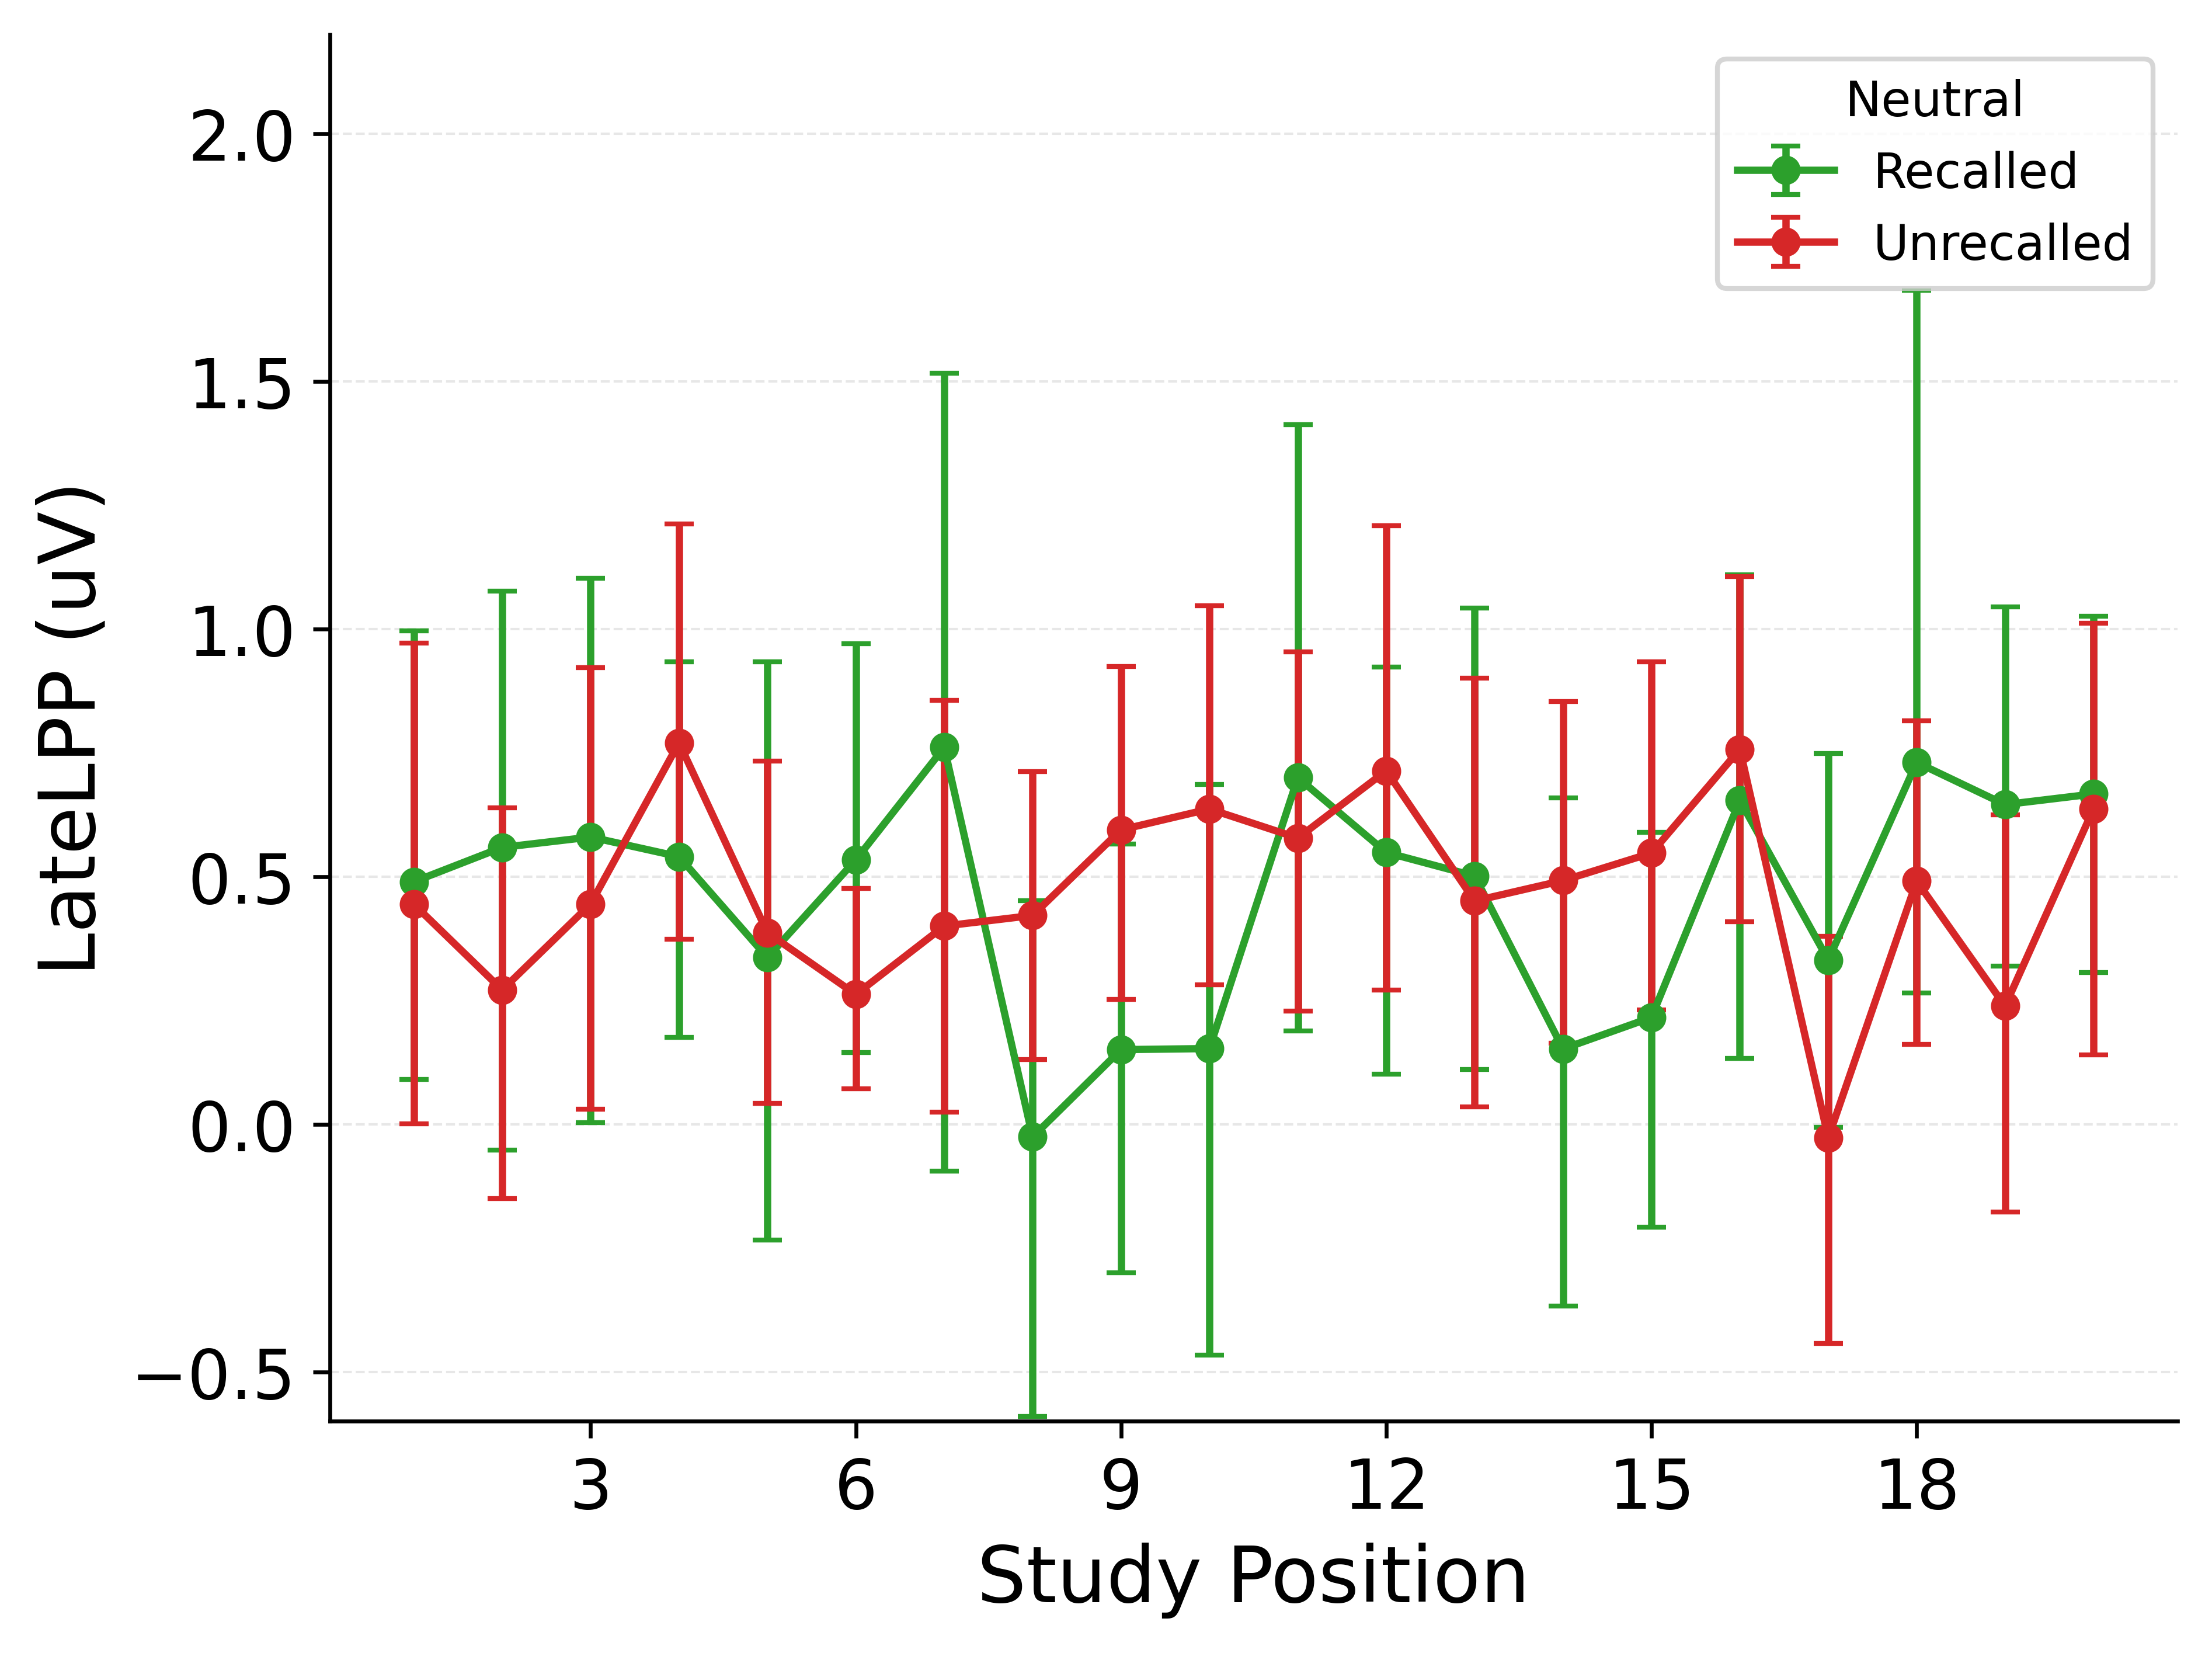

In [5]:
base_params = {
    "data_name": "TalmiEEG",
    "data_query": "data['subject'] > 0",
    "category_field": "condition",
    "labels": ["Recalled", "Unrecalled"],
    "ylim": [-.6, 2.2],
    "output_path": "figures/analyses/cat_lpp_by_recall_{}_{}.png",
}

for lpp_field in ["EarlyLPP", "LateLPP"]:
    color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]

    for category_value, contrast_name in zip([1, 2], ["Negative", "Neutral"]):
        output_path = base_params["output_path"].format(lpp_field, contrast_name)
        pm.execute_notebook(
            f"{find_project_root()}/analyses/templates/cat_lpp_by_recall.ipynb",
            f"{find_project_root()}/analyses/rendered/cat_lpp_by_recall_{lpp_field}_{contrast_name}.ipynb",
            parameters=base_params | {
                "category_value": category_value,
                "contrast_name": contrast_name,
                "lpp_field": lpp_field,
                "output_path": output_path,
                "color_cycle": [color_cycle.pop(0), color_cycle.pop(0)],
            },
            progress_bar=False,
            prepare_only=True,
        )
        print(f"![]({output_path})")
        display(Image(filename=output_path, width=600))
